# # Customer Return & Refund Analytics

## Business Problem
ShopKart E-Commerce has observed an increase in product returns, leading to higher refund costs and reduced profitability.

This project analyzes customer returns to identify key trends, refund patterns, and business insights using Python.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

In [ ]:
random.seed(42)
np.random.seed(42)

In [ ]:
cities = [
    "Mumbai","Pune","Delhi","Bengaluru","Hyderabad",
    "Chennai","Kolkata","Ahmedabad","Jaipur","Lucknow"
]

states = [
    "Maharashtra","Maharashtra","Delhi","Karnataka",
    "Telangana","Tamil Nadu","West Bengal",
    "Gujarat","Rajasthan","Uttar Pradesh"
]

categories = [
    "Electronics",
    "Clothing",
    "Home & Kitchen",
    "Books",
    "Sports",
    "Beauty"
]

products = [
    "Wireless Mouse",
    "Laptop Bag",
    "Running Shoes",
    "Face Wash",
    "Mixer Grinder",
    "Cricket Bat",
    "Novel",
    "Bluetooth Speaker",
    "Keyboard",
    "T-Shirt"
]

return_reasons = [
    "Damaged Product",
    "Wrong Item",
    "Late Delivery",
    "Changed Mind",
    "Quality Issue",
    "Size Issue",
    "Defective Product"
]

payment_methods = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Cash on Delivery",
    "Net Banking"
]

In [ ]:
# Generate one sample transaction

order_id = "ORD100001"

customer_id = "CUST" + str(random.randint(1000,9999))

order_date = datetime(2025,1,1) + timedelta(days=random.randint(0,364))

delivery_date = order_date + timedelta(days=random.randint(2,7))

returned = random.choice(["Yes","No"])

if returned == "Yes":
    return_date = delivery_date + timedelta(days=random.randint(1,15))
    return_reason = random.choice(return_reasons)
else:
    return_date = None
    return_reason = None

product = random.choice(products)

category = random.choice(categories)

city = random.choice(cities)

state = states[cities.index(city)]

quantity = random.randint(1,5)

unit_price = random.randint(300,5000)

revenue = quantity * unit_price

if returned == "Yes":
    refund_amount = revenue
else:
    refund_amount = 0

payment_method = random.choice(payment_methods)

rating = random.randint(1,5)

In [ ]:
print("Order ID:", order_id)
print("Customer ID:", customer_id)
print("Order Date:", order_date.date())
print("Delivery Date:", delivery_date.date())
print("Returned:", returned)
print("Return Date:", return_date)
print("Return Reason:", return_reason)
print("Product:", product)
print("Category:", category)
print("City:", city)
print("State:", state)
print("Quantity:", quantity)
print("Unit Price:", unit_price)
print("Revenue:", revenue)
print("Refund Amount:", refund_amount)
print("Payment Method:", payment_method)
print("Customer Rating:", rating)

Order ID: ORD100001
Customer ID: CUST2824
Order Date: 2025-01-13
Delivery Date: 2025-01-20
Returned: No
Return Date: None
Return Reason: None
Product: Face Wash
Category: Clothing
City: Delhi
State: Delhi
Quantity: 1
Unit Price: 4767
Revenue: 4767
Refund Amount: 0
Payment Method: UPI
Customer Rating: 5


In [ ]:
product_master = [
    {"Product":"Wireless Mouse","Category":"Electronics","Brand":"Logitech","MinPrice":500,"MaxPrice":1500},
    {"Product":"Mechanical Keyboard","Category":"Electronics","Brand":"Logitech","MinPrice":2500,"MaxPrice":7000},
    {"Product":"Bluetooth Speaker","Category":"Electronics","Brand":"JBL","MinPrice":2000,"MaxPrice":8000},
    {"Product":"Laptop Backpack","Category":"Accessories","Brand":"Wildcraft","MinPrice":1200,"MaxPrice":3500},
    {"Product":"T-Shirt","Category":"Clothing","Brand":"Nike","MinPrice":500,"MaxPrice":1800},
    {"Product":"Jeans","Category":"Clothing","Brand":"Levi's","MinPrice":1200,"MaxPrice":3500},
    {"Product":"Running Shoes","Category":"Clothing","Brand":"Adidas","MinPrice":2500,"MaxPrice":9000},
    {"Product":"Face Wash","Category":"Beauty","Brand":"Nivea","MinPrice":200,"MaxPrice":700},
    {"Product":"Shampoo","Category":"Beauty","Brand":"Dove","MinPrice":250,"MaxPrice":900},
    {"Product":"Perfume","Category":"Beauty","Brand":"Titan Skinn","MinPrice":1200,"MaxPrice":4000},
    {"Product":"Cricket Bat","Category":"Sports","Brand":"SG","MinPrice":1200,"MaxPrice":6000},
    {"Product":"Football","Category":"Sports","Brand":"Nivia","MinPrice":700,"MaxPrice":2500},
    {"Product":"Dumbbells","Category":"Sports","Brand":"Decathlon","MinPrice":1000,"MaxPrice":5000},
    {"Product":"Mixer Grinder","Category":"Home & Kitchen","Brand":"Philips","MinPrice":2500,"MaxPrice":7000},
    {"Product":"Pressure Cooker","Category":"Home & Kitchen","Brand":"Prestige","MinPrice":1200,"MaxPrice":3500},
    {"Product":"Dinner Set","Category":"Home & Kitchen","Brand":"Borosil","MinPrice":1500,"MaxPrice":6000},
    {"Product":"Python Programming Book","Category":"Books","Brand":"Pearson","MinPrice":500,"MaxPrice":1200},
    {"Product":"Data Analytics Handbook","Category":"Books","Brand":"O'Reilly","MinPrice":700,"MaxPrice":1800},
    {"Product":"Fiction Novel","Category":"Books","Brand":"Penguin","MinPrice":300,"MaxPrice":900}
]

product_master.head()

In [ ]:
product_master

[{'Product': 'Wireless Mouse',
  'Category': 'Electronics',
  'Brand': 'Logitech',
  'MinPrice': 500,
  'MaxPrice': 1500},
 {'Product': 'Mechanical Keyboard',
  'Category': 'Electronics',
  'Brand': 'Logitech',
  'MinPrice': 2500,
  'MaxPrice': 7000},
 {'Product': 'Bluetooth Speaker',
  'Category': 'Electronics',
  'Brand': 'JBL',
  'MinPrice': 2000,
  'MaxPrice': 8000},
 {'Product': 'Laptop Backpack',
  'Category': 'Accessories',
  'Brand': 'Wildcraft',
  'MinPrice': 1200,
  'MaxPrice': 3500},
 {'Product': 'T-Shirt',
  'Category': 'Clothing',
  'Brand': 'Nike',
  'MinPrice': 500,
  'MaxPrice': 1800},
 {'Product': 'Jeans',
  'Category': 'Clothing',
  'Brand': "Levi's",
  'MinPrice': 1200,
  'MaxPrice': 3500},
 {'Product': 'Running Shoes',
  'Category': 'Clothing',
  'Brand': 'Adidas',
  'MinPrice': 2500,
  'MaxPrice': 9000},
 {'Product': 'Face Wash',
  'Category': 'Beauty',
  'Brand': 'Nivea',
  'MinPrice': 200,
  'MaxPrice': 700},
 {'Product': 'Shampoo',
  'Category': 'Beauty',
  'Bra

In [ ]:
import pandas as pd

product_master = pd.DataFrame(product_master)

In [ ]:
product_master.head()

,Product,Category,Brand,MinPrice,MaxPrice
0,Wireless Mouse,Electronics,Logitech,500,1500
1,Mechanical Keyboard,Electronics,Logitech,2500,7000
2,Bluetooth Speaker,Electronics,JBL,2000,8000
3,Laptop Backpack,Accessories,Wildcraft,1200,3500
4,T-Shirt,Clothing,Nike,500,1800


In [ ]:
product_master.to_csv("/content/product_master.csv", index=False)

In [ ]:
seller_master = pd.DataFrame({
    "Seller_ID": [
        "S001","S002","S003","S004","S005",
        "S006","S007","S008","S009","S010"
    ],

    "Seller_Name": [
        "TechHub",
        "GadgetWorld",
        "FashionZone",
        "StyleKart",
        "HomeMart",
        "KitchenPro",
        "BookWorld",
        "SportsArena",
        "BeautyPlus",
        "MegaDeals"
    ],

    "Category": [
        "Electronics",
        "Electronics",
        "Clothing",
        "Clothing",
        "Home & Kitchen",
        "Home & Kitchen",
        "Books",
        "Sports",
        "Beauty",
        "Accessories"
    ],

    "Seller_Rating":[
        4.8,4.5,4.7,3.4,4.2,
        4.1,4.9,4.3,4.0,3.2
    ],

    "Quality":[
        "Excellent",
        "Good",
        "Excellent",
        "Poor",
        "Good",
        "Good",
        "Excellent",
        "Good",
        "Average",
        "Poor"
    ]
})

In [ ]:
seller_master.head()


,Seller_ID,Seller_Name,Category,Seller_Rating,Quality
0,S001,TechHub,Electronics,4.8,Excellent
1,S002,GadgetWorld,Electronics,4.5,Good
2,S003,FashionZone,Clothing,4.7,Excellent
3,S004,StyleKart,Clothing,3.4,Poor
4,S005,HomeMart,Home & Kitchen,4.2,Good


In [ ]:
seller_master.to_csv("/content/seller_master.csv", index=False)

In [ ]:
# ============================================
# Customer Master
# ============================================

In [ ]:
first_names = [
    "Aarav","Vivaan","Aditya","Arjun","Krishna",
    "Diya","Ananya","Priya","Riya","Sneha",
    "Rahul","Aman","Rohan","Neha","Pooja"
]

last_names = [
    "Sharma","Patel","Singh","Gupta","Verma",
    "Joshi","Nair","Iyer","Khan","Fernandes"
]

cities = [
    "Mumbai","Pune","Delhi","Bengaluru","Hyderabad",
    "Chennai","Ahmedabad","Kolkata","Jaipur","Lucknow"
]

states = {
    "Mumbai":"Maharashtra",
    "Pune":"Maharashtra",
    "Delhi":"Delhi",
    "Bengaluru":"Karnataka",
    "Hyderabad":"Telangana",
    "Chennai":"Tamil Nadu",
    "Ahmedabad":"Gujarat",
    "Kolkata":"West Bengal",
    "Jaipur":"Rajasthan",
    "Lucknow":"Uttar Pradesh"
}

memberships = [
    "Regular",
    "Silver",
    "Gold",
    "Platinum"
]

In [ ]:
customers = []

In [ ]:
import random
for i in range(1,5001):

    city = random.choice(cities)

    customers.append({

        "Customer_ID": f"C{i:05d}",

        "Customer_Name":
        random.choice(first_names) + " " +
        random.choice(last_names),

        "Age":
        random.randint(18,65),

        "Gender":
        random.choice(["Male","Female"]),

        "City":
        city,

        "State":
        states[city],

        "Membership":
        random.choices(
            memberships,
            weights=[50,25,15,10]
        )[0]
    })

In [ ]:
customer_master = pd.DataFrame(customers)

In [ ]:
customer_master.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership
0,C00001,Aarav Sharma,23,Male,Ahmedabad,Gujarat,Regular
1,C00002,Aarav Khan,30,Female,Lucknow,Uttar Pradesh,Regular
2,C00003,Krishna Sharma,28,Female,Lucknow,Uttar Pradesh,Regular
3,C00004,Arjun Joshi,24,Male,Delhi,Delhi,Regular
4,C00005,Neha Joshi,56,Female,Chennai,Tamil Nadu,Gold


In [ ]:
customer_master.to_csv("/content/customer_master.csv", index=False)

In [ ]:
customer_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    5000 non-null   object
 1   Customer_Name  5000 non-null   object
 2   Age            5000 non-null   int64 
 3   Gender         5000 non-null   object
 4   City           5000 non-null   object
 5   State          5000 non-null   object
 6   Membership     5000 non-null   object
dtypes: int64(1), object(6)
memory usage: 273.6+ KB


In [ ]:
customer_master.describe(include="all")

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership
count,5000,5000,5000.000000,5000,5000,5000,5000
unique,5000,150,NaN,2,10,9,4
top,C05000,Aarav Singh,NaN,Male,Ahmedabad,Maharashtra,Regular
freq,1,54,NaN,2554,537,989,2575
mean,NaN,NaN,41.586600,NaN,NaN,NaN,NaN
std,NaN,NaN,13.766307,NaN,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,30.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,42.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,54.000000,NaN,NaN,NaN,NaN


In [ ]:
# ============================================
# Return Policy
# ============================================

In [ ]:
return_policy = pd.DataFrame({

    "Return_Reason":[
        "Damaged Product",
        "Wrong Item",
        "Defective Product",
        "Late Delivery",
        "Quality Issue",
        "Size Issue",
        "Changed Mind"
    ],

    "Refund_Percentage":[
        100,
        100,
        100,
        100,
        100,
        90,
        85
    ]
})

In [ ]:
return_policy

,Return_Reason,Refund_Percentage
0,Damaged Product,100
1,Wrong Item,100
2,Defective Product,100
3,Late Delivery,100
4,Quality Issue,100
5,Size Issue,90
6,Changed Mind,85


In [ ]:
return_policy.to_csv("/content/return_policy.csv", index=False)

In [ ]:
# ============================================
# Transaction Generation
# ============================================

transactions = []

In [ ]:
# Pick one random customer
customer = customer_master.sample(1).iloc[0]

# Pick one random product
product = product_master.sample(1).iloc[0]

# Pick a seller who sells that product's category
seller = seller_master[
    seller_master["Category"] == product["Category"]
].sample(1).iloc[0]

In [ ]:
type(product_master)

pandas.core.frame.DataFrame

In [ ]:
product_master = pd.DataFrame(product_master)

In [ ]:
# Pick one random customer
customer = customer_master.sample(1).iloc[0]

# Pick one random product
product = product_master.sample(1).iloc[0]

# Pick a seller who sells that product's category
seller = seller_master[
    seller_master["Category"] == product["Category"]
].sample(1).iloc[0]

In [ ]:
print(customer)
print(product)
print(seller)

Customer_ID           C03520
Customer_Name    Vivaan Iyer
Age                       63
Gender                  Male
City                 Kolkata
State            West Bengal
Membership              Gold
Name: 3519, dtype: object
Product     Wireless Mouse
Category       Electronics
Brand             Logitech
MinPrice               500
MaxPrice              1500
Name: 0, dtype: object
Seller_ID               S002
Seller_Name      GadgetWorld
Category         Electronics
Seller_Rating            4.5
Quality                 Good
Name: 1, dtype: object


In [ ]:
from datetime import datetime, timedelta

# Order ID
order_id = "ORD000001"

# Order Date
start_date = datetime(2024,1,1)
end_date = datetime(2025,12,31)

order_date = start_date + timedelta(
    days=random.randint(0,(end_date-start_date).days)
)

# Quantity
quantity = random.randint(1,3)

# Unit Price
unit_price = random.randint(
    product["MinPrice"],
    product["MaxPrice"]
)

# Revenue
revenue = quantity * unit_price

In [ ]:
seller_master.head()

,Seller_ID,Seller_Name,Category,Seller_Rating,Quality
0,S001,TechHub,Electronics,4.8,Excellent
1,S002,GadgetWorld,Electronics,4.5,Good
2,S003,FashionZone,Clothing,4.7,Excellent
3,S004,StyleKart,Clothing,3.4,Poor
4,S005,HomeMart,Home & Kitchen,4.2,Good


In [ ]:
seller_master["Expected_Return_Rate"] = [
    0.02,
    0.05,
    0.03,
    0.20,
    0.08,
    0.07,
    0.02,
    0.06,
    0.10,
    0.25
]

In [ ]:
seller_master.head()

,Seller_ID,Seller_Name,Category,Seller_Rating,Quality,Expected_Return_Rate
0,S001,TechHub,Electronics,4.8,Excellent,0.02
1,S002,GadgetWorld,Electronics,4.5,Good,0.05
2,S003,FashionZone,Clothing,4.7,Excellent,0.03
3,S004,StyleKart,Clothing,3.4,Poor,0.20
4,S005,HomeMart,Home & Kitchen,4.2,Good,0.08


In [ ]:
# Pick one random customer
customer = customer_master.sample(1).iloc[0]

# Pick one random product
product = product_master.sample(1).iloc[0]

# Pick a seller who sells that product's category
seller = seller_master[
    seller_master["Category"] == product["Category"]
].sample(1).iloc[0]

In [ ]:
returned = random.random() < seller["Expected_Return_Rate"]

In [ ]:
if returned:
    reason = return_policy.sample(1).iloc[0]
    return_reason = reason["Return_Reason"]
    refund_percentage = reason["Refund_Percentage"]
else:
    return_reason = "Not Returned"
    refund_percentage = 0

In [ ]:
refund_amount = revenue * refund_percentage / 100

In [ ]:
delivery_date = order_date + timedelta(days=random.randint(2,7))

In [ ]:
if returned:
    return_date = delivery_date + timedelta(days=random.randint(1,15))
else:
    return_date = None

In [ ]:
product_master.insert(
    0,
    "Product_ID",
    [f"P{i:03d}" for i in range(1, len(product_master)+1)]
)

In [ ]:
product_master.head()

,Product_ID,Product,Category,Brand,MinPrice,MaxPrice
0,P001,Wireless Mouse,Electronics,Logitech,500,1500
1,P002,Mechanical Keyboard,Electronics,Logitech,2500,7000
2,P003,Bluetooth Speaker,Electronics,JBL,2000,8000
3,P004,Laptop Backpack,Accessories,Wildcraft,1200,3500
4,P005,T-Shirt,Clothing,Nike,500,1800


In [ ]:
seller_master.columns

Index(['Seller_ID', 'Seller_Name', 'Category', 'Seller_Rating', 'Quality',
       'Expected_Return_Rate'],
      dtype='object')

In [ ]:
customer_master.columns

Index(['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'State',
       'Membership'],
      dtype='object')

In [ ]:
product_master.columns

Index(['Product_ID', 'Product', 'Category', 'Brand', 'MinPrice', 'MaxPrice'], dtype='object')

In [ ]:
product = product_master.sample(1).iloc[0]

In [ ]:
print(product)

Product_ID        P006
Product          Jeans
Category      Clothing
Brand           Levi's
MinPrice          1200
MaxPrice          3500
Name: 5, dtype: object


In [ ]:
product_master.head()

,Product_ID,Product,Category,Brand,MinPrice,MaxPrice
0,P001,Wireless Mouse,Electronics,Logitech,500,1500
1,P002,Mechanical Keyboard,Electronics,Logitech,2500,7000
2,P003,Bluetooth Speaker,Electronics,JBL,2000,8000
3,P004,Laptop Backpack,Accessories,Wildcraft,1200,3500
4,P005,T-Shirt,Clothing,Nike,500,1800


In [ ]:
transaction = {
    "Order_ID": order_id,

    "Customer_ID": customer["Customer_ID"],
    "Customer_Name": customer["Customer_Name"],

    "Product_ID": product["Product_ID"],
    "Product": product["Product"],
    "Category": product["Category"],
    "Brand": product["Brand"],

    "Seller_ID": seller["Seller_ID"],
    "Seller_Name": seller["Seller_Name"],

    "Order_Date": order_date,
    "Delivery_Date": delivery_date,
    "Return_Date": return_date,

    "Quantity": quantity,
    "Unit_Price": unit_price,
    "Revenue": revenue,

    "Returned": returned,
    "Return_Reason": return_reason,

    "Refund_Percentage": refund_percentage,
    "Refund_Amount": refund_amount,

    "City": customer["City"],
    "State": customer["State"],
    "Membership": customer["Membership"]
}

In [ ]:
# ============================================
# Transaction Generator Function
# ============================================

In [ ]:
def generate_transaction(order_no):

    # Pick a random customer
    customer = customer_master.sample(1).iloc[0]

    # Pick a random product
    product = product_master.sample(1).iloc[0]

    # Pick a seller who sells that product category
    seller = seller_master[
        seller_master["Category"] == product["Category"]
    ].sample(1).iloc[0]

    # Order ID
    order_id = f"ORD{order_no:06d}"

    # Random Order Date
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2025, 12, 31)

    order_date = start_date + timedelta(
        days=random.randint(0, (end_date - start_date).days)
    )

    # Delivery Date
    delivery_date = order_date + timedelta(
        days=random.randint(2, 7)
    )

    # Quantity
    quantity = random.randint(1, 3)

    # Unit Price
    unit_price = random.randint(
        product["MinPrice"],
        product["MaxPrice"]
    )

    # Revenue
    revenue = quantity * unit_price

    # Return Decision
    returned = random.random() < seller["Expected_Return_Rate"]

    if returned:

        reason = return_policy.sample(1).iloc[0]

        return_reason = reason["Return_Reason"]
        refund_percentage = reason["Refund_Percentage"]

        return_date = delivery_date + timedelta(
            days=random.randint(1, 15)
        )

    else:

        return_reason = "Not Returned"
        refund_percentage = 0
        return_date = None

    # Refund Amount
    refund_amount = revenue * refund_percentage / 100

    # Final Transaction
    transaction = {

        # Order Details
        "Order_ID": order_id,
        "Order_Date": order_date,
        "Delivery_Date": delivery_date,
        "Return_Date": return_date,

        # Customer Details
        "Customer_ID": customer["Customer_ID"],
        "Customer_Name": customer["Customer_Name"],
        "Age": customer["Age"],
        "Gender": customer["Gender"],
        "City": customer["City"],
        "State": customer["State"],
        "Membership": customer["Membership"],

        # Product Details
        "Product_ID": product["Product_ID"],
        "Product": product["Product"],
        "Category": product["Category"],
        "Brand": product["Brand"],

        # Seller Details
        "Seller_ID": seller["Seller_ID"],
        "Seller_Name": seller["Seller_Name"],
        "Seller_Rating": seller["Seller_Rating"],

        # Sales
        "Quantity": quantity,
        "Unit_Price": unit_price,
        "Revenue": revenue,

        # Returns
        "Returned": returned,
        "Return_Reason": return_reason,
        "Refund_Percentage": refund_percentage,
        "Refund_Amount": refund_amount

    }

    return transaction

In [ ]:
pd.DataFrame([generate_transaction(1)])

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
0,ORD000001,2025-03-01,2025-03-06,None,C02907,Arjun Gupta,27,Female,Jaipur,Rajasthan,...,S008,SportsArena,4.3,1,2013,2013,False,Not Returned,0,0.0


In [ ]:
transactions = []

for i in range(1,11):
    transactions.append(generate_transaction(i))

transactions_df = pd.DataFrame(transactions)
transactions_df

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
0,ORD000001,2025-01-29,2025-01-31,NaT,C03285,Aarav Singh,56,Male,Hyderabad,Telangana,...,S004,StyleKart,3.4,1,677,677,False,Not Returned,0,0.00
1,ORD000002,2025-05-02,2025-05-06,NaT,C02603,Vivaan Sharma,18,Male,Pune,Maharashtra,...,S010,MegaDeals,3.2,2,1883,3766,False,Not Returned,0,0.00
2,ORD000003,2024-09-20,2024-09-22,2024-09-27,C00617,Aman Patel,40,Female,Bengaluru,Karnataka,...,S002,GadgetWorld,4.5,1,5975,5975,True,Changed Mind,85,5078.75
3,ORD000004,2025-06-22,2025-06-24,NaT,C03431,Krishna Nair,32,Male,Delhi,Delhi,...,S008,SportsArena,4.3,3,2304,6912,False,Not Returned,0,0.00
4,ORD000005,2025-02-05,2025-02-08,NaT,C04410,Riya Nair,21,Female,Ahmedabad,Gujarat,...,S001,TechHub,4.8,1,2985,2985,False,Not Returned,0,0.00
5,ORD000006,2024-08-27,2024-08-29,NaT,C02848,Aarav Gupta,27,Male,Ahmedabad,Gujarat,...,S009,BeautyPlus,4.0,3,626,1878,False,Not Returned,0,0.00
6,ORD000007,2024-01-21,2024-01-24,NaT,C01477,Aditya Sharma,63,Male,Chennai,Tamil Nadu,...,S007,BookWorld,4.9,3,644,1932,False,Not Returned,0,0.00
7,ORD000008,2025-03-22,2025-03-29,NaT,C04761,Arjun Iyer,35,Female,Bengaluru,Karnataka,...,S009,BeautyPlus,4.0,2,310,620,False,Not Returned,0,0.00
8,ORD000009,2024-02-03,2024-02-10,NaT,C00381,Riya Iyer,26,Female,Jaipur,Rajasthan,...,S008,SportsArena,4.3,2,5622,11244,False,Not Returned,0,0.00
9,ORD000010,2024-05-08,2024-05-15,NaT,C01706,Rahul Khan,32,Male,Kolkata,West Bengal,...,S008,SportsArena,4.3,3,2181,6543,False,Not Returned,0,0.00


In [ ]:
seller_master.columns

Index(['Seller_ID', 'Seller_Name', 'Category', 'Seller_Rating', 'Quality',
       'Expected_Return_Rate'],
      dtype='object')

In [ ]:
transactions = []

for i in range(1, 101):
    transactions.append(generate_transaction(i))

transactions_df = pd.DataFrame(transactions)

In [ ]:
transactions_df.head()

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
0,ORD000001,2024-08-21,2024-08-28,NaT,C04056,Pooja Iyer,44,Female,Lucknow,Uttar Pradesh,...,S002,GadgetWorld,4.5,1,3919,3919,False,Not Returned,0,0.0
1,ORD000002,2024-08-08,2024-08-12,NaT,C00759,Ananya Khan,52,Female,Delhi,Delhi,...,S006,KitchenPro,4.1,1,6850,6850,False,Not Returned,0,0.0
2,ORD000003,2025-06-27,2025-06-29,NaT,C04428,Sneha Iyer,21,Female,Kolkata,West Bengal,...,S002,GadgetWorld,4.5,2,6113,12226,False,Not Returned,0,0.0
3,ORD000004,2024-04-02,2024-04-09,NaT,C04287,Neha Khan,28,Female,Lucknow,Uttar Pradesh,...,S009,BeautyPlus,4.0,2,3863,7726,False,Not Returned,0,0.0
4,ORD000005,2024-05-28,2024-06-01,NaT,C00993,Aman Patel,29,Female,Jaipur,Rajasthan,...,S003,FashionZone,4.7,3,996,2988,False,Not Returned,0,0.0


In [ ]:
len(transactions_df)

100

In [ ]:
transactions_df["Returned"].value_counts()

,count
Returned,
False,92
True,8


In [ ]:
transactions_df["Returned"].mean() * 100
transactions_df["Revenue"].sum()
transactions_df["Refund_Amount"].sum()
transactions_df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
transactions_df.groupby("Seller_Name")["Returned"].mean().sort_values(ascending=False)

,Returned
Seller_Name,
StyleKart,0.307692
MegaDeals,0.250000
FashionZone,0.200000
KitchenPro,0.125000
BookWorld,0.000000
BeautyPlus,0.000000
HomeMart,0.000000
GadgetWorld,0.000000
SportsArena,0.000000


In [ ]:
transactions = []

for i in range(1, 100001):
    transactions.append(generate_transaction(i))

transactions_df = pd.DataFrame(transactions)

In [ ]:
transactions_df.to_csv("/content/transactions.csv", index=False)

In [ ]:
from google.colab import files
files.download("/content/transactions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# Exploratory Data Analysis (EDA)
# ============================================

In [ ]:
import pandas as pd

transactions_df = pd.read_csv("transactions.csv")

In [ ]:
transactions_df.head()

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
0,ORD000001,2024-07-01,2024-07-08,NaN,C02911,Priya Nair,47,Male,Pune,Maharashtra,...,S009,BeautyPlus,4.0,2,1623,3246,False,Not Returned,0,0.0
1,ORD000002,2024-11-08,2024-11-14,NaN,C02394,Sneha Nair,21,Male,Lucknow,Uttar Pradesh,...,S003,FashionZone,4.7,2,4285,8570,False,Not Returned,0,0.0
2,ORD000003,2025-07-28,2025-08-03,NaN,C02933,Rohan Nair,31,Male,Jaipur,Rajasthan,...,S001,TechHub,4.8,1,590,590,False,Not Returned,0,0.0
3,ORD000004,2024-08-04,2024-08-10,NaN,C03463,Sneha Khan,29,Female,Jaipur,Rajasthan,...,S002,GadgetWorld,4.5,3,2938,8814,False,Not Returned,0,0.0
4,ORD000005,2024-06-19,2024-06-26,NaN,C01080,Priya Khan,36,Female,Delhi,Delhi,...,S010,MegaDeals,3.2,1,1666,1666,False,Not Returned,0,0.0


In [ ]:
transactions_df.shape

(100000, 25)

In [ ]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Order_ID           100000 non-null  object 
 1   Order_Date         100000 non-null  object 
 2   Delivery_Date      100000 non-null  object 
 3   Return_Date        7854 non-null    object 
 4   Customer_ID        100000 non-null  object 
 5   Customer_Name      100000 non-null  object 
 6   Age                100000 non-null  int64  
 7   Gender             100000 non-null  object 
 8   City               100000 non-null  object 
 9   State              100000 non-null  object 
 10  Membership         100000 non-null  object 
 11  Product_ID         100000 non-null  object 
 12  Product            100000 non-null  object 
 13  Category           100000 non-null  object 
 14  Brand              100000 non-null  object 
 15  Seller_ID          100000 non-null  object 
 16  Sel

In [ ]:
# ============================================
# Data Quality Checks
# ============================================

In [ ]:
transactions_df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Delivery_Date,0
Return_Date,92146
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
State,0


In [ ]:
# ============================================
# Duplicate Check
# ============================================

In [ ]:
transactions_df.duplicated().sum()

np.int64(0)

In [ ]:
transactions_df.describe()

,Age,Seller_Rating,Quantity,Unit_Price,Revenue,Refund_Percentage,Refund_Amount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.655050,4.281137,2.001200,2515.301200,5036.859900,7.573350,392.125956
std,13.753854,0.488295,0.817915,1899.249387,4592.079293,25.991525,1827.024605
min,18.000000,3.200000,1.000000,200.000000,200.000000,0.000000,0.000000
25%,30.000000,4.000000,1.000000,942.000000,1671.000000,0.000000,0.000000
50%,42.000000,4.300000,2.000000,1976.000000,3453.000000,0.000000,0.000000
75%,54.000000,4.700000,3.000000,3522.000000,6861.000000,0.000000,0.000000
max,65.000000,4.900000,3.000000,9000.000000,26988.000000,100.000000,26868.000000


Analysis 1 — Overall Return Analysis

In [ ]:
transactions_df["Revenue"].sum()

np.int64(503685990)

In [ ]:
Total_Revenue = transactions_df["Revenue"].sum()
print(f"Total Revenue: ₹{Total_Revenue:,.0f}")

Total Revenue: ₹503,685,990


In [ ]:
Total_Refund = transactions_df["Refund_Amount"].sum()
print(f"Total Refund: ₹{Total_Refund:,.0f}")

Total Refund: ₹39,212,596


In [ ]:
Total_Orders = transactions_df["Order_ID"].nunique()
print(f"Total Orders: {Total_Orders:,.0f}")

Total Orders: 100,000


In [ ]:
Net_Revenue = Total_Revenue-Total_Refund
print(f"Net Revenue: ₹{Net_Revenue:,.0f}")

Net Revenue: ₹464,473,394


In [ ]:
returned_orders = transactions_df["Returned"].sum()

print(f"Returned Orders: {returned_orders}")

Returned Orders: 7854


In [ ]:
return_rate = returned_orders/Total_Orders*100
print(f"Return Rate:{return_rate: .2f}%")

Return Rate: 7.85%


In [ ]:
average_order_value = Total_Revenue / Total_Orders

print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹5,036.86


In [ ]:
returned_df = transactions_df[transactions_df["Returned"]==True]


In [ ]:
return_reason_counts=(
    returned_df["Return_Reason"]
    .value_counts()
    .reset_index()
)
return_reason_counts.columns=["Return_Reason","No_of_Returns"]
return_reason_counts

,Return_Reason,No_of_Returns
0,Size Issue,1143
1,Wrong Item,1141
2,Damaged Product,1136
3,Quality Issue,1124
4,Changed Mind,1109
5,Late Delivery,1102
6,Defective Product,1099


In [ ]:
return_reason_counts["Percentage"] = (
    return_reason_counts["No_of_Returns"]
    / returned_orders
) * 100

return_reason_counts["Percentage"] = (
    return_reason_counts["Percentage"]
    .round(2)
)

return_reason_counts

,Return_Reason,No_of_Returns,Percentage
0,Size Issue,1143,14.55
1,Wrong Item,1141,14.53
2,Damaged Product,1136,14.46
3,Quality Issue,1124,14.31
4,Changed Mind,1109,14.12
5,Late Delivery,1102,14.03
6,Defective Product,1099,13.99


In [ ]:
# ============================================
# Return Reason Analysis
# ============================================

In [ ]:
import matplotlib.pyplot as plt


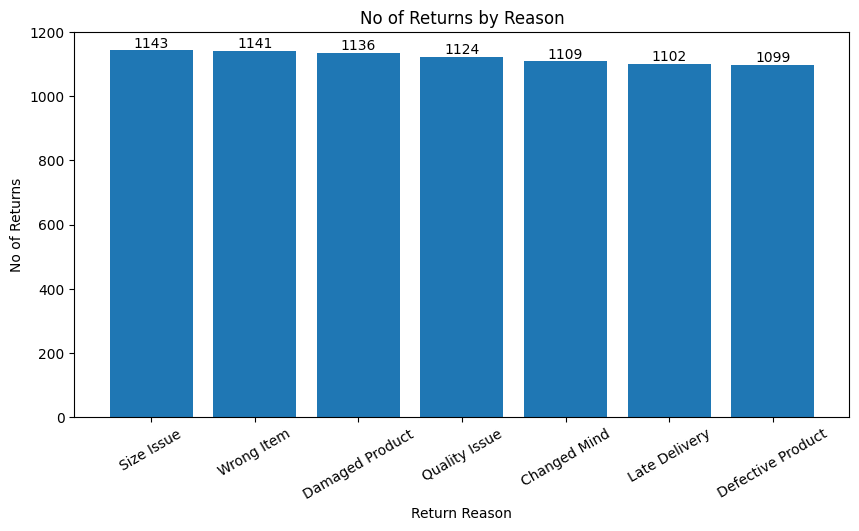

In [ ]:
plt.figure(figsize=(10,5))
bars = plt.bar(
    return_reason_counts["Return_Reason"],
    return_reason_counts["No_of_Returns"]
)
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )
plt.title("No of Returns by Reason")
plt.xlabel("Return Reason")
plt.ylabel("No of Returns")
plt.xticks(rotation=30)
plt.show()

In [ ]:
## 📌 Business Insights



In [ ]:
return_reason_counts.to_csv(
    "return_reason_analysis.csv",
    index=False
)

Analysis 3 — Seller-Level Return Analysis

In [ ]:
seller_orders = (
    transactions_df
    .groupby("Seller_ID")
    .size()
    .reset_index(name="Total_Orders")
)

seller_orders

,Seller_ID,Total_Orders
0,S001,7721
1,S002,7953
2,S003,7909
3,S004,7902
4,S005,7766
5,S006,7941
6,S007,15879
7,S008,15959
8,S009,15644
9,S010,5326


In [ ]:
seller_returns = (
    transactions_df[transactions_df["Returned"] == True]
    .groupby("Seller_ID")
    .size()
    .reset_index(name="Returned_Orders")
)

seller_returns

,Seller_ID,Returned_Orders
0,S001,174
1,S002,415
2,S003,229
3,S004,1528
4,S005,628
5,S006,541
6,S007,366
7,S008,967
8,S009,1613
9,S010,1393


In [ ]:
seller_analysis = seller_orders.merge(
    seller_returns,
    on="Seller_ID",
    how="left"
)

seller_analysis

,Seller_ID,Total_Orders,Returned_Orders
0,S001,7721,174
1,S002,7953,415
2,S003,7909,229
3,S004,7902,1528
4,S005,7766,628
5,S006,7941,541
6,S007,15879,366
7,S008,15959,967
8,S009,15644,1613
9,S010,5326,1393


In [ ]:
seller_analysis["Return_Rate"] = (
    seller_analysis["Returned_Orders"]
    / seller_analysis["Total_Orders"]
) * 100

seller_analysis["Return_Rate"] = (
    seller_analysis["Return_Rate"].round(2)
)

seller_analysis

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate
0,S001,7721,174,2.25
1,S002,7953,415,5.22
2,S003,7909,229,2.90
3,S004,7902,1528,19.34
4,S005,7766,628,8.09
5,S006,7941,541,6.81
6,S007,15879,366,2.30
7,S008,15959,967,6.06
8,S009,15644,1613,10.31
9,S010,5326,1393,26.15


In [ ]:
company_return_rate = (
    returned_orders / Total_Orders
) * 100

print(f"Company Return Rate: {company_return_rate:.2f}%")

Company Return Rate: 7.85%


In [ ]:
high_return_sellers = seller_analysis[
    seller_analysis["Return_Rate"] > 10
]

high_return_sellers

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate
3,S004,7902,1528,19.34
8,S009,15644,1613,10.31
9,S010,5326,1393,26.15


In [ ]:
seller_refunds = (
    transactions_df
    .groupby("Seller_ID")["Refund_Amount"]
    .sum()
    .reset_index()
)

seller_refunds.columns = ["Seller_ID", "Total_Refund_Amount"]

seller_refunds

,Seller_ID,Total_Refund_Amount
0,S001,1219501.85
1,S002,2817991.40
2,S003,1533207.30
3,S004,9558742.40
4,S005,4413414.85
5,S006,3848267.60
6,S007,649047.45
7,S008,5076865.55
8,S009,3765620.65
9,S010,6329936.60


In [ ]:
seller_analysis = seller_analysis.merge(
    seller_refunds,
    on="Seller_ID",
    how="left"
)

seller_analysis

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount
0,S001,7721,174,2.25,1219501.85
1,S002,7953,415,5.22,2817991.40
2,S003,7909,229,2.90,1533207.30
3,S004,7902,1528,19.34,9558742.40
4,S005,7766,628,8.09,4413414.85
5,S006,7941,541,6.81,3848267.60
6,S007,15879,366,2.30,649047.45
7,S008,15959,967,6.06,5076865.55
8,S009,15644,1613,10.31,3765620.65
9,S010,5326,1393,26.15,6329936.60


In [ ]:
seller_revenue = (
    transactions_df
    .groupby("Seller_ID")["Revenue"]
    .sum()
    .reset_index()
)

seller_revenue.columns = ["Seller_ID", "Total_Revenue"]

seller_revenue

,Seller_ID,Total_Revenue
0,S001,54631528
1,S002,57064702
2,S003,49426301
3,S004,49782718
4,S005,56559894
5,S006,58175196
6,S007,28407140
7,S008,86669395
8,S009,37988838
9,S010,24980278


In [ ]:
seller_analysis = seller_analysis.merge(
    seller_revenue,
    on="Seller_ID",
    how="left"
)

seller_analysis


,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue
0,S001,7721,174,2.25,1219501.85,54631528
1,S002,7953,415,5.22,2817991.40,57064702
2,S003,7909,229,2.90,1533207.30,49426301
3,S004,7902,1528,19.34,9558742.40,49782718
4,S005,7766,628,8.09,4413414.85,56559894
5,S006,7941,541,6.81,3848267.60,58175196
6,S007,15879,366,2.30,649047.45,28407140
7,S008,15959,967,6.06,5076865.55,86669395
8,S009,15644,1613,10.31,3765620.65,37988838
9,S010,5326,1393,26.15,6329936.60,24980278


In [ ]:
seller_analysis["Net_Revenue"] = (
    seller_analysis["Total_Revenue"]
    - seller_analysis["Total_Refund_Amount"]
)

seller_analysis

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue
0,S001,7721,174,2.25,1219501.85,54631528,53412026.15
1,S002,7953,415,5.22,2817991.40,57064702,54246710.60
2,S003,7909,229,2.90,1533207.30,49426301,47893093.70
3,S004,7902,1528,19.34,9558742.40,49782718,40223975.60
4,S005,7766,628,8.09,4413414.85,56559894,52146479.15
5,S006,7941,541,6.81,3848267.60,58175196,54326928.40
6,S007,15879,366,2.30,649047.45,28407140,27758092.55
7,S008,15959,967,6.06,5076865.55,86669395,81592529.45
8,S009,15644,1613,10.31,3765620.65,37988838,34223217.35
9,S010,5326,1393,26.15,6329936.60,24980278,18650341.40


In [ ]:
seller_analysis["Refund_Loss_Percentage"] = (
    seller_analysis["Total_Refund_Amount"]
    / seller_analysis["Total_Revenue"]
) * 100

seller_analysis["Refund_Loss_Percentage"] = (
    seller_analysis["Refund_Loss_Percentage"].round(2)
)

seller_analysis

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
0,S001,7721,174,2.25,1219501.85,54631528,53412026.15,2.23
1,S002,7953,415,5.22,2817991.40,57064702,54246710.60,4.94
2,S003,7909,229,2.90,1533207.30,49426301,47893093.70,3.10
3,S004,7902,1528,19.34,9558742.40,49782718,40223975.60,19.20
4,S005,7766,628,8.09,4413414.85,56559894,52146479.15,7.80
5,S006,7941,541,6.81,3848267.60,58175196,54326928.40,6.61
6,S007,15879,366,2.30,649047.45,28407140,27758092.55,2.28
7,S008,15959,967,6.06,5076865.55,86669395,81592529.45,5.86
8,S009,15644,1613,10.31,3765620.65,37988838,34223217.35,9.91
9,S010,5326,1393,26.15,6329936.60,24980278,18650341.40,25.34


In [ ]:
seller_analysis["Risk_Category"] = seller_analysis["Return_Rate"].apply(
    lambda x: "High Risk" if x > 10
    else "Medium Risk" if x >= 5
    else "Low Risk"
)

seller_analysis

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage,Risk_Category
0,S001,7721,174,2.25,1219501.85,54631528,53412026.15,2.23,Low Risk
1,S002,7953,415,5.22,2817991.40,57064702,54246710.60,4.94,Medium Risk
2,S003,7909,229,2.90,1533207.30,49426301,47893093.70,3.10,Low Risk
3,S004,7902,1528,19.34,9558742.40,49782718,40223975.60,19.20,High Risk
4,S005,7766,628,8.09,4413414.85,56559894,52146479.15,7.80,Medium Risk
5,S006,7941,541,6.81,3848267.60,58175196,54326928.40,6.61,Medium Risk
6,S007,15879,366,2.30,649047.45,28407140,27758092.55,2.28,Low Risk
7,S008,15959,967,6.06,5076865.55,86669395,81592529.45,5.86,Medium Risk
8,S009,15644,1613,10.31,3765620.65,37988838,34223217.35,9.91,High Risk
9,S010,5326,1393,26.15,6329936.60,24980278,18650341.40,25.34,High Risk


In [ ]:
seller_risk_report = seller_analysis.sort_values(
    "Return_Rate",
    ascending=False
)

seller_risk_report

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage,Risk_Category
9,S010,5326,1393,26.15,6329936.60,24980278,18650341.40,25.34,High Risk
3,S004,7902,1528,19.34,9558742.40,49782718,40223975.60,19.20,High Risk
8,S009,15644,1613,10.31,3765620.65,37988838,34223217.35,9.91,High Risk
4,S005,7766,628,8.09,4413414.85,56559894,52146479.15,7.80,Medium Risk
5,S006,7941,541,6.81,3848267.60,58175196,54326928.40,6.61,Medium Risk
7,S008,15959,967,6.06,5076865.55,86669395,81592529.45,5.86,Medium Risk
1,S002,7953,415,5.22,2817991.40,57064702,54246710.60,4.94,Medium Risk
2,S003,7909,229,2.90,1533207.30,49426301,47893093.70,3.10,Low Risk
6,S007,15879,366,2.30,649047.45,28407140,27758092.55,2.28,Low Risk
0,S001,7721,174,2.25,1219501.85,54631528,53412026.15,2.23,Low Risk


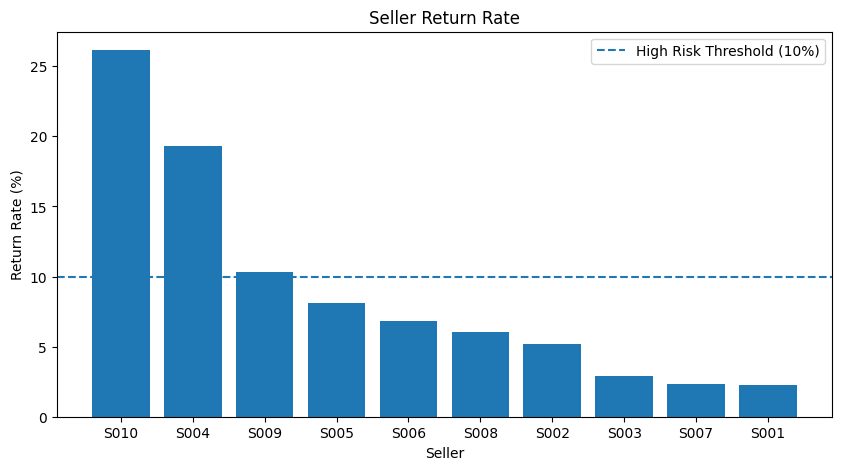

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    seller_risk_report["Seller_ID"],
    seller_risk_report["Return_Rate"]
)

plt.axhline(
    y=10,
    linestyle="--",
    label="High Risk Threshold (10%)"
)

plt.title("Seller Return Rate")
plt.xlabel("Seller")
plt.ylabel("Return Rate (%)")

plt.legend()

plt.show()

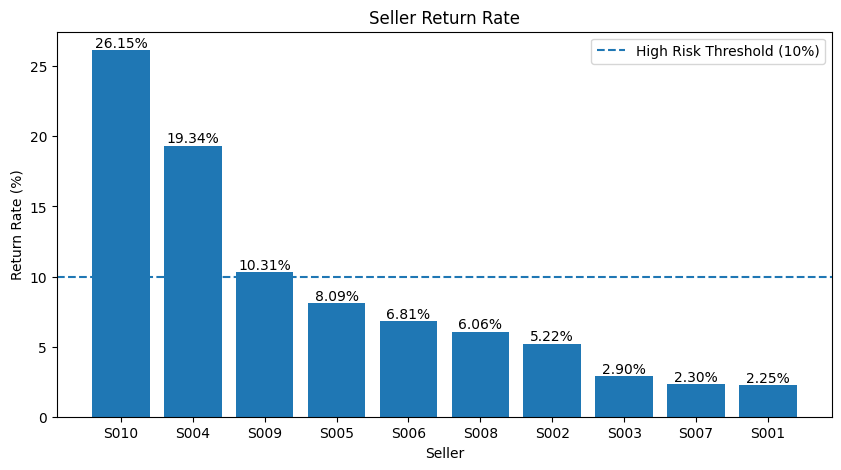

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    seller_risk_report["Seller_ID"],
    seller_risk_report["Return_Rate"]
)

plt.axhline(
    y=10,
    linestyle="--",
    label="High Risk Threshold (10%)"
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Seller Return Rate")
plt.xlabel("Seller")
plt.ylabel("Return Rate (%)")

plt.legend()

plt.show()

In [ ]:
high_risk_sellers = seller_risk_report[
    seller_risk_report["Risk_Category"] == "High Risk"
]

high_risk_sellers

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage,Risk_Category
9,S010,5326,1393,26.15,6329936.60,24980278,18650341.40,25.34,High Risk
3,S004,7902,1528,19.34,9558742.40,49782718,40223975.60,19.20,High Risk
8,S009,15644,1613,10.31,3765620.65,37988838,34223217.35,9.91,High Risk


In [ ]:
high_risk_seller_table = high_risk_sellers[
    [
        "Seller_ID",
        "Total_Orders",
        "Returned_Orders",
        "Return_Rate",
        "Total_Refund_Amount",
        "Refund_Loss_Percentage",
        "Net_Revenue"
    ]
]

high_risk_seller_table

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Refund_Loss_Percentage,Net_Revenue
9,S010,5326,1393,26.15,6329936.60,25.34,18650341.40
3,S004,7902,1528,19.34,9558742.40,19.20,40223975.60
8,S009,15644,1613,10.31,3765620.65,9.91,34223217.35


In [ ]:
high_risk_seller_table = high_risk_seller_table.sort_values(
    "Return_Rate",
    ascending=False
)

high_risk_seller_table

,Seller_ID,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Refund_Loss_Percentage,Net_Revenue
9,S010,5326,1393,26.15,6329936.60,25.34,18650341.40
3,S004,7902,1528,19.34,9558742.40,19.20,40223975.60
8,S009,15644,1613,10.31,3765620.65,9.91,34223217.35


In [ ]:
high_risk_transactions = transactions_df[
    transactions_df["Seller_ID"].isin(
        high_risk_seller_table["Seller_ID"]
    )
]

high_risk_transactions

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
0,ORD000001,2024-07-01,2024-07-08,NaN,C02911,Priya Nair,47,Male,Pune,Maharashtra,...,S009,BeautyPlus,4.0,2,1623,3246,False,Not Returned,0,0.00
4,ORD000005,2024-06-19,2024-06-26,NaN,C01080,Priya Khan,36,Female,Delhi,Delhi,...,S010,MegaDeals,3.2,1,1666,1666,False,Not Returned,0,0.00
6,ORD000007,2025-05-20,2025-05-24,2025-05-28,C04358,Rahul Sharma,46,Female,Bengaluru,Karnataka,...,S004,StyleKart,3.4,1,851,851,True,Changed Mind,85,723.35
12,ORD000013,2025-01-15,2025-01-21,2025-02-02,C00577,Arjun Singh,55,Male,Pune,Maharashtra,...,S010,MegaDeals,3.2,2,3262,6524,True,Size Issue,90,5871.60
14,ORD000015,2025-07-15,2025-07-17,NaN,C00649,Neha Patel,32,Male,Kolkata,West Bengal,...,S009,BeautyPlus,4.0,1,446,446,False,Not Returned,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99982,ORD099983,2025-11-12,2025-11-14,NaN,C02624,Neha Nair,44,Female,Jaipur,Rajasthan,...,S009,BeautyPlus,4.0,1,452,452,False,Not Returned,0,0.00
99985,ORD099986,2025-10-03,2025-10-05,NaN,C02719,Aman Verma,64,Female,Hyderabad,Telangana,...,S009,BeautyPlus,4.0,2,674,1348,False,Not Returned,0,0.00
99991,ORD099992,2024-02-18,2024-02-25,NaN,C03737,Aditya Iyer,57,Female,Ahmedabad,Gujarat,...,S009,BeautyPlus,4.0,3,2448,7344,False,Not Returned,0,0.00
99992,ORD099993,2024-03-05,2024-03-10,NaN,C00540,Diya Nair,38,Male,Ahmedabad,Gujarat,...,S009,BeautyPlus,4.0,1,437,437,False,Not Returned,0,0.00


In [ ]:
high_risk_transactions = transactions_df[
    transactions_df["Seller_ID"].isin(
        high_risk_seller_table["Seller_ID"]
    )
]

high_risk_transactions

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
0,ORD000001,2024-07-01,2024-07-08,NaN,C02911,Priya Nair,47,Male,Pune,Maharashtra,...,S009,BeautyPlus,4.0,2,1623,3246,False,Not Returned,0,0.00
4,ORD000005,2024-06-19,2024-06-26,NaN,C01080,Priya Khan,36,Female,Delhi,Delhi,...,S010,MegaDeals,3.2,1,1666,1666,False,Not Returned,0,0.00
6,ORD000007,2025-05-20,2025-05-24,2025-05-28,C04358,Rahul Sharma,46,Female,Bengaluru,Karnataka,...,S004,StyleKart,3.4,1,851,851,True,Changed Mind,85,723.35
12,ORD000013,2025-01-15,2025-01-21,2025-02-02,C00577,Arjun Singh,55,Male,Pune,Maharashtra,...,S010,MegaDeals,3.2,2,3262,6524,True,Size Issue,90,5871.60
14,ORD000015,2025-07-15,2025-07-17,NaN,C00649,Neha Patel,32,Male,Kolkata,West Bengal,...,S009,BeautyPlus,4.0,1,446,446,False,Not Returned,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99982,ORD099983,2025-11-12,2025-11-14,NaN,C02624,Neha Nair,44,Female,Jaipur,Rajasthan,...,S009,BeautyPlus,4.0,1,452,452,False,Not Returned,0,0.00
99985,ORD099986,2025-10-03,2025-10-05,NaN,C02719,Aman Verma,64,Female,Hyderabad,Telangana,...,S009,BeautyPlus,4.0,2,674,1348,False,Not Returned,0,0.00
99991,ORD099992,2024-02-18,2024-02-25,NaN,C03737,Aditya Iyer,57,Female,Ahmedabad,Gujarat,...,S009,BeautyPlus,4.0,3,2448,7344,False,Not Returned,0,0.00
99992,ORD099993,2024-03-05,2024-03-10,NaN,C00540,Diya Nair,38,Male,Ahmedabad,Gujarat,...,S009,BeautyPlus,4.0,1,437,437,False,Not Returned,0,0.00


In [ ]:
high_risk_returns = high_risk_transactions[
    high_risk_transactions["Returned"] == True
]

high_risk_returns

,Order_ID,Order_Date,Delivery_Date,Return_Date,Customer_ID,Customer_Name,Age,Gender,City,State,...,Seller_ID,Seller_Name,Seller_Rating,Quantity,Unit_Price,Revenue,Returned,Return_Reason,Refund_Percentage,Refund_Amount
6,ORD000007,2025-05-20,2025-05-24,2025-05-28,C04358,Rahul Sharma,46,Female,Bengaluru,Karnataka,...,S004,StyleKart,3.4,1,851,851,True,Changed Mind,85,723.35
12,ORD000013,2025-01-15,2025-01-21,2025-02-02,C00577,Arjun Singh,55,Male,Pune,Maharashtra,...,S010,MegaDeals,3.2,2,3262,6524,True,Size Issue,90,5871.60
42,ORD000043,2024-06-21,2024-06-25,2024-07-06,C02565,Aarav Iyer,26,Male,Ahmedabad,Gujarat,...,S010,MegaDeals,3.2,3,2308,6924,True,Changed Mind,85,5885.40
76,ORD000077,2025-09-11,2025-09-16,2025-09-26,C00897,Riya Gupta,23,Female,Kolkata,West Bengal,...,S010,MegaDeals,3.2,2,2538,5076,True,Defective Product,100,5076.00
86,ORD000087,2025-09-28,2025-10-03,2025-10-16,C01081,Arjun Gupta,61,Female,Kolkata,West Bengal,...,S009,BeautyPlus,4.0,1,1530,1530,True,Defective Product,100,1530.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99854,ORD099855,2024-07-01,2024-07-06,2024-07-19,C00257,Rohan Sharma,46,Male,Jaipur,Rajasthan,...,S009,BeautyPlus,4.0,1,3233,3233,True,Late Delivery,100,3233.00
99864,ORD099865,2024-12-12,2024-12-16,2024-12-24,C03461,Priya Nair,19,Male,Lucknow,Uttar Pradesh,...,S009,BeautyPlus,4.0,1,1922,1922,True,Size Issue,90,1729.80
99898,ORD099899,2025-09-09,2025-09-16,2025-09-23,C04703,Pooja Singh,21,Male,Hyderabad,Telangana,...,S004,StyleKart,3.4,2,1277,2554,True,Defective Product,100,2554.00
99912,ORD099913,2025-07-30,2025-08-04,2025-08-10,C01677,Vivaan Nair,63,Male,Pune,Maharashtra,...,S010,MegaDeals,3.2,1,1565,1565,True,Late Delivery,100,1565.00


In [ ]:
high_risk_reason_analysis = (
    high_risk_returns
    .groupby(["Seller_ID", "Return_Reason"])
    .size()
    .reset_index(name="Return_Count")
)

high_risk_reason_analysis

,Seller_ID,Return_Reason,Return_Count
0,S004,Changed Mind,223
1,S004,Damaged Product,204
2,S004,Defective Product,215
3,S004,Late Delivery,219
4,S004,Quality Issue,240
5,S004,Size Issue,222
6,S004,Wrong Item,205
7,S009,Changed Mind,236
8,S009,Damaged Product,238
9,S009,Defective Product,211


In [ ]:
high_risk_reason_analysis["Percentage"] = (
    high_risk_reason_analysis
    .groupby("Seller_ID")["Return_Count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

high_risk_reason_analysis["Percentage"] = (
    high_risk_reason_analysis["Percentage"].round(2)
)

high_risk_reason_analysis

,Seller_ID,Return_Reason,Return_Count,Percentage
0,S004,Changed Mind,223,14.59
1,S004,Damaged Product,204,13.35
2,S004,Defective Product,215,14.07
3,S004,Late Delivery,219,14.33
4,S004,Quality Issue,240,15.71
5,S004,Size Issue,222,14.53
6,S004,Wrong Item,205,13.42
7,S009,Changed Mind,236,14.63
8,S009,Damaged Product,238,14.76
9,S009,Defective Product,211,13.08


In [ ]:
high_risk_reason_analysis = high_risk_reason_analysis.sort_values(
    ["Seller_ID", "Percentage"],
    ascending=[True, False]
)

high_risk_reason_analysis

,Seller_ID,Return_Reason,Return_Count,Percentage
4,S004,Quality Issue,240,15.71
0,S004,Changed Mind,223,14.59
5,S004,Size Issue,222,14.53
3,S004,Late Delivery,219,14.33
2,S004,Defective Product,215,14.07
6,S004,Wrong Item,205,13.42
1,S004,Damaged Product,204,13.35
13,S009,Wrong Item,239,14.82
8,S009,Damaged Product,238,14.76
7,S009,Changed Mind,236,14.63


In [ ]:
top_reason_by_seller = (
    high_risk_reason_analysis
    .groupby("Seller_ID")
    .first()
    .reset_index()
)

top_reason_by_seller

,Seller_ID,Return_Reason,Return_Count,Percentage
0,S004,Quality Issue,240,15.71
1,S009,Wrong Item,239,14.82
2,S010,Size Issue,225,16.15


In [ ]:
top_reason_by_seller.to_csv(
    "top_return_reason_by_high_risk_seller.csv",
    index=False
)

Analysis 3 — Category-Level Return Analysis

In [ ]:
category_orders = (
    transactions_df
    .groupby("Category")
    .size()
    .reset_index(name="Total_Orders")
)

category_orders

,Category,Total_Orders
0,Accessories,5326
1,Beauty,15644
2,Books,15879
3,Clothing,15811
4,Electronics,15674
5,Home & Kitchen,15707
6,Sports,15959


In [ ]:
category_returns = (
    transactions_df[transactions_df["Returned"] == True]
    .groupby("Category")
    .size()
    .reset_index(name="Returned_Orders")
)

category_returns

,Category,Returned_Orders
0,Accessories,1393
1,Beauty,1613
2,Books,366
3,Clothing,1757
4,Electronics,589
5,Home & Kitchen,1169
6,Sports,967


In [ ]:
category_analysis = category_orders.merge(
    category_returns,
    on="Category",
    how="left"
)

category_analysis

,Category,Total_Orders,Returned_Orders
0,Accessories,5326,1393
1,Beauty,15644,1613
2,Books,15879,366
3,Clothing,15811,1757
4,Electronics,15674,589
5,Home & Kitchen,15707,1169
6,Sports,15959,967


In [ ]:
category_analysis["Return_Rate"] = (
    category_analysis["Returned_Orders"]
    / category_analysis["Total_Orders"]
) * 100

category_analysis["Return_Rate"] = (
    category_analysis["Return_Rate"].round(2)
)

category_analysis

,Category,Total_Orders,Returned_Orders,Return_Rate
0,Accessories,5326,1393,26.15
1,Beauty,15644,1613,10.31
2,Books,15879,366,2.30
3,Clothing,15811,1757,11.11
4,Electronics,15674,589,3.76
5,Home & Kitchen,15707,1169,7.44
6,Sports,15959,967,6.06


In [ ]:
category_refunds = (
    transactions_df
    .groupby("Category")["Refund_Amount"]
    .sum()
    .reset_index()
)

category_refunds.columns = [
    "Category",
    "Total_Refund_Amount"
]

category_refunds

,Category,Total_Refund_Amount
0,Accessories,6329936.60
1,Beauty,3765620.65
2,Books,649047.45
3,Clothing,11091949.70
4,Electronics,4037493.25
5,Home & Kitchen,8261682.45
6,Sports,5076865.55


In [ ]:
category_revenue = (
    transactions_df
    .groupby("Category")["Revenue"]
    .sum()
    .reset_index()
)

category_revenue.columns = [
    "Category",
    "Total_Revenue"
]

category_revenue

,Category,Total_Revenue
0,Accessories,24980278
1,Beauty,37988838
2,Books,28407140
3,Clothing,99209019
4,Electronics,111696230
5,Home & Kitchen,114735090
6,Sports,86669395


In [ ]:
category_analysis = category_analysis.merge(
    category_refunds,
    on="Category",
    how="left"
)

category_analysis = category_analysis.merge(
    category_revenue,
    on="Category",
    how="left"
)

category_analysis

,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue
0,Accessories,5326,1393,26.15,6329936.60,24980278
1,Beauty,15644,1613,10.31,3765620.65,37988838
2,Books,15879,366,2.30,649047.45,28407140
3,Clothing,15811,1757,11.11,11091949.70,99209019
4,Electronics,15674,589,3.76,4037493.25,111696230
5,Home & Kitchen,15707,1169,7.44,8261682.45,114735090
6,Sports,15959,967,6.06,5076865.55,86669395


In [ ]:
category_analysis["Net_Revenue"] = (
    category_analysis["Total_Revenue"]
    - category_analysis["Total_Refund_Amount"]

)
pd.options.display.float_format = '{:,.2f}'.format
category_analysis

,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue
0,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40"
1,Beauty,15644,1613,10.31,"3,765,620.65",37988838,"34,223,217.35"
2,Books,15879,366,2.30,"649,047.45",28407140,"27,758,092.55"
3,Clothing,15811,1757,11.11,"11,091,949.70",99209019,"88,117,069.30"
4,Electronics,15674,589,3.76,"4,037,493.25",111696230,"107,658,736.75"
5,Home & Kitchen,15707,1169,7.44,"8,261,682.45",114735090,"106,473,407.55"
6,Sports,15959,967,6.06,"5,076,865.55",86669395,"81,592,529.45"


In [ ]:
category_analysis["Refund_Loss_Percentage"] = (
    category_analysis["Total_Refund_Amount"]
    / category_analysis["Total_Revenue"]
) * 100

category_analysis["Refund_Loss_Percentage"] = (
    category_analysis["Refund_Loss_Percentage"].round(2)
)

category_analysis

,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
0,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
1,Beauty,15644,1613,10.31,"3,765,620.65",37988838,"34,223,217.35",9.91
2,Books,15879,366,2.30,"649,047.45",28407140,"27,758,092.55",2.28
3,Clothing,15811,1757,11.11,"11,091,949.70",99209019,"88,117,069.30",11.18
4,Electronics,15674,589,3.76,"4,037,493.25",111696230,"107,658,736.75",3.61
5,Home & Kitchen,15707,1169,7.44,"8,261,682.45",114735090,"106,473,407.55",7.20
6,Sports,15959,967,6.06,"5,076,865.55",86669395,"81,592,529.45",5.86


In [ ]:
category_risk_report = category_analysis.sort_values(
    "Return_Rate",
    ascending=False
)

category_risk_report

,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
0,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
3,Clothing,15811,1757,11.11,"11,091,949.70",99209019,"88,117,069.30",11.18
1,Beauty,15644,1613,10.31,"3,765,620.65",37988838,"34,223,217.35",9.91
5,Home & Kitchen,15707,1169,7.44,"8,261,682.45",114735090,"106,473,407.55",7.20
6,Sports,15959,967,6.06,"5,076,865.55",86669395,"81,592,529.45",5.86
4,Electronics,15674,589,3.76,"4,037,493.25",111696230,"107,658,736.75",3.61
2,Books,15879,366,2.30,"649,047.45",28407140,"27,758,092.55",2.28


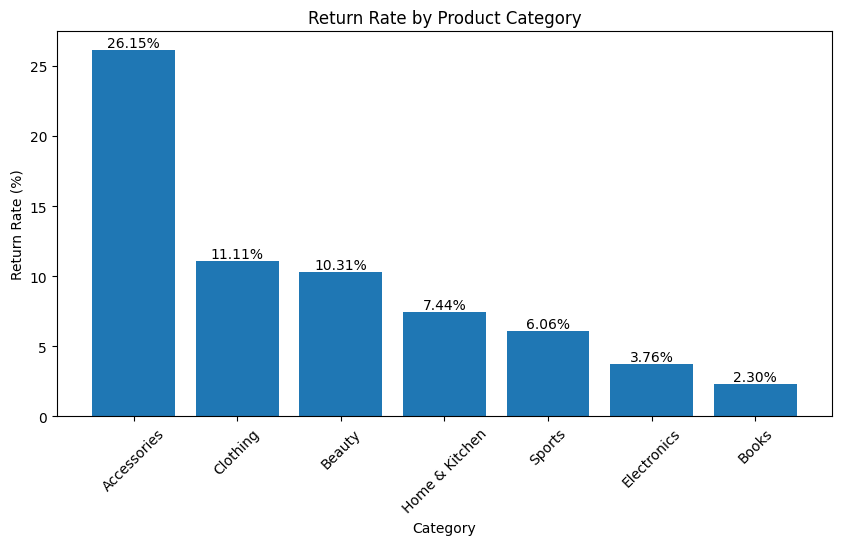

In [ ]:

plt.figure(figsize=(10,5))

bars = plt.bar(
    category_risk_report["Category"],
    category_risk_report["Return_Rate"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Return Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=45)

plt.show()

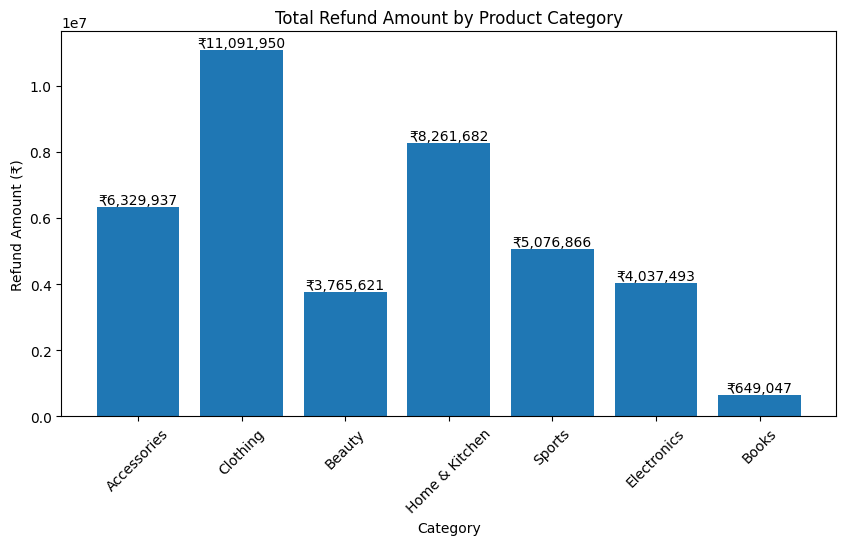

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    category_risk_report["Category"],
    category_risk_report["Total_Refund_Amount"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Total Refund Amount by Product Category")
plt.xlabel("Category")
plt.ylabel("Refund Amount (₹)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
highest_return_category = category_risk_report.iloc[0]

print(
    f"Highest Return Rate Category: "
    f"{highest_return_category['Category']}"
)

print(
    f"Return Rate: "
    f"{highest_return_category['Return_Rate']:.2f}%"
)

Highest Return Rate Category: Accessories
Return Rate: 26.15%


In [ ]:
highest_refund_category = (
    category_analysis
    .sort_values(
        "Total_Refund_Amount",
        ascending=False
    )
    .iloc[0]
)

print(
    f"Highest Refund Cost Category: "
    f"{highest_refund_category['Category']}"
)

print(
    f"Total Refund Amount: "
    f"₹{highest_refund_category['Total_Refund_Amount']:,.2f}"
)

Highest Refund Cost Category: Clothing
Total Refund Amount: ₹11,091,949.70


In [ ]:
category_analysis.to_csv(
    "category_return_analysis.csv",
    index=False
)

In [ ]:
category_risk_report.to_csv(
    "category_risk_report.csv",
    index=False
)

Analysis 4 — Product-Level Return Analysis

In [ ]:
product_orders = (
    transactions_df
    .groupby(["Product_ID", "Product", "Category"])
    .size()
    .reset_index(name="Total_Orders")
)

product_orders

,Product_ID,Product,Category,Total_Orders
0,P001,Wireless Mouse,Electronics,5196
1,P002,Mechanical Keyboard,Electronics,5232
2,P003,Bluetooth Speaker,Electronics,5246
3,P004,Laptop Backpack,Accessories,5326
4,P005,T-Shirt,Clothing,5250
5,P006,Jeans,Clothing,5204
6,P007,Running Shoes,Clothing,5357
7,P008,Face Wash,Beauty,5202
8,P009,Shampoo,Beauty,5227
9,P010,Perfume,Beauty,5215


In [ ]:
product_returns = (
    transactions_df[transactions_df["Returned"] == True]
    .groupby(["Product_ID", "Product", "Category"])
    .size()
    .reset_index(name="Returned_Orders")
)

product_returns

,Product_ID,Product,Category,Returned_Orders
0,P001,Wireless Mouse,Electronics,196
1,P002,Mechanical Keyboard,Electronics,201
2,P003,Bluetooth Speaker,Electronics,192
3,P004,Laptop Backpack,Accessories,1393
4,P005,T-Shirt,Clothing,565
5,P006,Jeans,Clothing,575
6,P007,Running Shoes,Clothing,617
7,P008,Face Wash,Beauty,538
8,P009,Shampoo,Beauty,539
9,P010,Perfume,Beauty,536


In [ ]:
product_analysis = product_orders.merge(
    product_returns,
    on=["Product_ID", "Product", "Category"],
    how="left"
)

product_analysis["Returned_Orders"] = (
    product_analysis["Returned_Orders"].fillna(0)
)

product_analysis

,Product_ID,Product,Category,Total_Orders,Returned_Orders
0,P001,Wireless Mouse,Electronics,5196,196
1,P002,Mechanical Keyboard,Electronics,5232,201
2,P003,Bluetooth Speaker,Electronics,5246,192
3,P004,Laptop Backpack,Accessories,5326,1393
4,P005,T-Shirt,Clothing,5250,565
5,P006,Jeans,Clothing,5204,575
6,P007,Running Shoes,Clothing,5357,617
7,P008,Face Wash,Beauty,5202,538
8,P009,Shampoo,Beauty,5227,539
9,P010,Perfume,Beauty,5215,536


In [ ]:
product_analysis["Return_Rate"] = (
    product_analysis["Returned_Orders"]
    / product_analysis["Total_Orders"]
) * 100

product_analysis["Return_Rate"] = (
    product_analysis["Return_Rate"].round(2)
)

product_analysis

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate
0,P001,Wireless Mouse,Electronics,5196,196,3.77
1,P002,Mechanical Keyboard,Electronics,5232,201,3.84
2,P003,Bluetooth Speaker,Electronics,5246,192,3.66
3,P004,Laptop Backpack,Accessories,5326,1393,26.15
4,P005,T-Shirt,Clothing,5250,565,10.76
5,P006,Jeans,Clothing,5204,575,11.05
6,P007,Running Shoes,Clothing,5357,617,11.52
7,P008,Face Wash,Beauty,5202,538,10.34
8,P009,Shampoo,Beauty,5227,539,10.31
9,P010,Perfume,Beauty,5215,536,10.28


In [ ]:
product_refunds = (
    transactions_df
    .groupby(["Product_ID", "Product", "Category"])["Refund_Amount"]
    .sum()
    .reset_index()
)

product_refunds.columns = [
    "Product_ID",
    "Product",
    "Category",
    "Total_Refund_Amount"
]

product_refunds

,Product_ID,Product,Category,Total_Refund_Amount
0,P001,Wireless Mouse,Electronics,"365,800.95"
1,P002,Mechanical Keyboard,Electronics,"1,830,764.35"
2,P003,Bluetooth Speaker,Electronics,"1,840,927.95"
3,P004,Laptop Backpack,Accessories,"6,329,936.60"
4,P005,T-Shirt,Clothing,"1,250,819.65"
5,P006,Jeans,Clothing,"2,623,702.45"
6,P007,Running Shoes,Clothing,"7,217,427.60"
7,P008,Face Wash,Beauty,"488,707.60"
8,P009,Shampoo,Beauty,"597,817.40"
9,P010,Perfume,Beauty,"2,679,095.65"


In [ ]:
product_revenue = (
    transactions_df
    .groupby(["Product_ID", "Product", "Category"])["Revenue"]
    .sum()
    .reset_index()
)

product_revenue.columns = [
    "Product_ID",
    "Product",
    "Category",
    "Total_Revenue"
]

product_revenue

,Product_ID,Product,Category,Total_Revenue
0,P001,Wireless Mouse,Electronics,10443633
1,P002,Mechanical Keyboard,Electronics,49371324
2,P003,Bluetooth Speaker,Electronics,51881273
3,P004,Laptop Backpack,Accessories,24980278
4,P005,T-Shirt,Clothing,12162049
5,P006,Jeans,Clothing,24794932
6,P007,Running Shoes,Clothing,62252038
7,P008,Face Wash,Beauty,4699227
8,P009,Shampoo,Beauty,6006300
9,P010,Perfume,Beauty,27283311


In [ ]:
product_analysis = product_analysis.merge(
    product_refunds,
    on=["Product_ID", "Product", "Category"],
    how="left"
)

product_analysis = product_analysis.merge(
    product_revenue,
    on=["Product_ID", "Product", "Category"],
    how="left"
)

product_analysis

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue
0,P001,Wireless Mouse,Electronics,5196,196,3.77,"365,800.95",10443633
1,P002,Mechanical Keyboard,Electronics,5232,201,3.84,"1,830,764.35",49371324
2,P003,Bluetooth Speaker,Electronics,5246,192,3.66,"1,840,927.95",51881273
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278
4,P005,T-Shirt,Clothing,5250,565,10.76,"1,250,819.65",12162049
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038
7,P008,Face Wash,Beauty,5202,538,10.34,"488,707.60",4699227
8,P009,Shampoo,Beauty,5227,539,10.31,"597,817.40",6006300
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311


In [ ]:
product_analysis["Net_Revenue"] = (
    product_analysis["Total_Revenue"]
    - product_analysis["Total_Refund_Amount"]
)

product_analysis

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue
0,P001,Wireless Mouse,Electronics,5196,196,3.77,"365,800.95",10443633,"10,077,832.05"
1,P002,Mechanical Keyboard,Electronics,5232,201,3.84,"1,830,764.35",49371324,"47,540,559.65"
2,P003,Bluetooth Speaker,Electronics,5246,192,3.66,"1,840,927.95",51881273,"50,040,345.05"
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40"
4,P005,T-Shirt,Clothing,5250,565,10.76,"1,250,819.65",12162049,"10,911,229.35"
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55"
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40"
7,P008,Face Wash,Beauty,5202,538,10.34,"488,707.60",4699227,"4,210,519.40"
8,P009,Shampoo,Beauty,5227,539,10.31,"597,817.40",6006300,"5,408,482.60"
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35"


In [ ]:
product_analysis["Refund_Loss_Percentage"] = (
    product_analysis["Total_Refund_Amount"]
    / product_analysis["Total_Revenue"]
) * 100

product_analysis["Refund_Loss_Percentage"] = (
    product_analysis["Refund_Loss_Percentage"].round(2)
)

product_analysis

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
0,P001,Wireless Mouse,Electronics,5196,196,3.77,"365,800.95",10443633,"10,077,832.05",3.50
1,P002,Mechanical Keyboard,Electronics,5232,201,3.84,"1,830,764.35",49371324,"47,540,559.65",3.71
2,P003,Bluetooth Speaker,Electronics,5246,192,3.66,"1,840,927.95",51881273,"50,040,345.05",3.55
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
4,P005,T-Shirt,Clothing,5250,565,10.76,"1,250,819.65",12162049,"10,911,229.35",10.28
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55",10.58
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40",11.59
7,P008,Face Wash,Beauty,5202,538,10.34,"488,707.60",4699227,"4,210,519.40",10.40
8,P009,Shampoo,Beauty,5227,539,10.31,"597,817.40",6006300,"5,408,482.60",9.95
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35",9.82


In [ ]:
product_return_report = product_analysis.sort_values(
    "Return_Rate",
    ascending=False
)

product_return_report

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40",11.59
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55",10.58
4,P005,T-Shirt,Clothing,5250,565,10.76,"1,250,819.65",12162049,"10,911,229.35",10.28
7,P008,Face Wash,Beauty,5202,538,10.34,"488,707.60",4699227,"4,210,519.40",10.40
8,P009,Shampoo,Beauty,5227,539,10.31,"597,817.40",6006300,"5,408,482.60",9.95
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35",9.82
13,P014,Mixer Grinder,Home & Kitchen,5357,412,7.69,"3,741,041.30",51144240,"47,403,198.70",7.31
15,P016,Dinner Set,Home & Kitchen,5144,387,7.52,"2,816,403.65",38914663,"36,098,259.35",7.24
14,P015,Pressure Cooker,Home & Kitchen,5206,370,7.11,"1,704,237.50",24676187,"22,971,949.50",6.91


In [ ]:
top_return_products = product_return_report.head(10)

top_return_products

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40",11.59
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55",10.58
4,P005,T-Shirt,Clothing,5250,565,10.76,"1,250,819.65",12162049,"10,911,229.35",10.28
7,P008,Face Wash,Beauty,5202,538,10.34,"488,707.60",4699227,"4,210,519.40",10.40
8,P009,Shampoo,Beauty,5227,539,10.31,"597,817.40",6006300,"5,408,482.60",9.95
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35",9.82
13,P014,Mixer Grinder,Home & Kitchen,5357,412,7.69,"3,741,041.30",51144240,"47,403,198.70",7.31
15,P016,Dinner Set,Home & Kitchen,5144,387,7.52,"2,816,403.65",38914663,"36,098,259.35",7.24
14,P015,Pressure Cooker,Home & Kitchen,5206,370,7.11,"1,704,237.50",24676187,"22,971,949.50",6.91


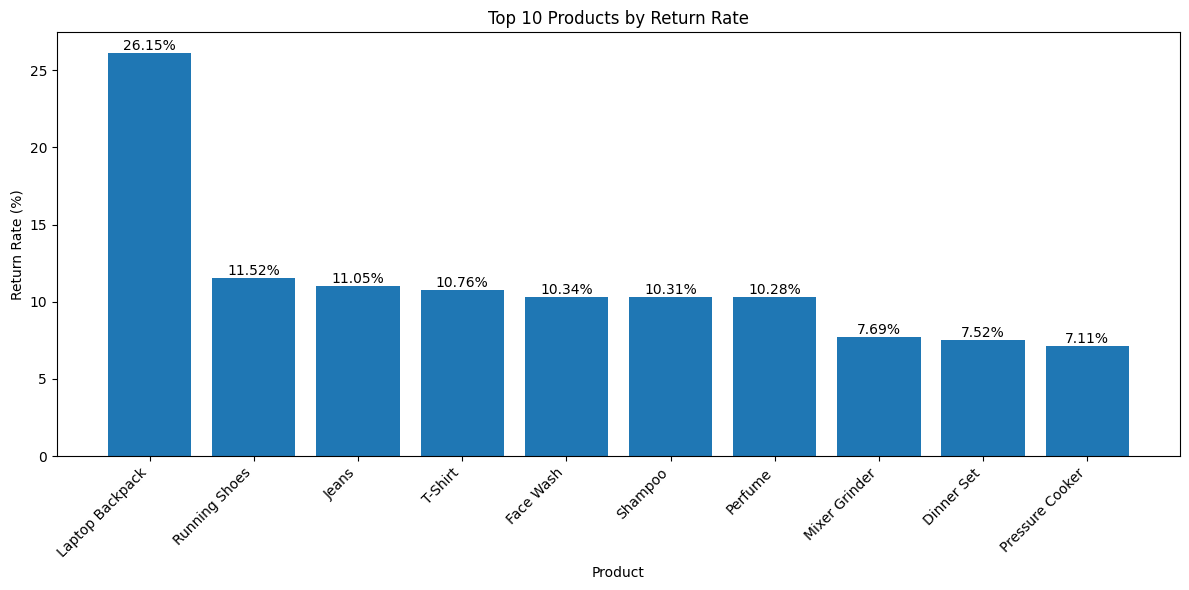

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_return_products["Product"],
    top_return_products["Return_Rate"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Top 10 Products by Return Rate")
plt.xlabel("Product")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
top_refund_products = (
    product_analysis
    .sort_values(
        "Total_Refund_Amount",
        ascending=False
    )
    .head(10)
)

top_refund_products

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40",11.59
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
13,P014,Mixer Grinder,Home & Kitchen,5357,412,7.69,"3,741,041.30",51144240,"47,403,198.70",7.31
15,P016,Dinner Set,Home & Kitchen,5144,387,7.52,"2,816,403.65",38914663,"36,098,259.35",7.24
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35",9.82
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55",10.58
10,P011,Cricket Bat,Sports,5328,318,5.97,"2,193,299.40",38139115,"35,945,815.60",5.75
12,P013,Dumbbells,Sports,5302,326,6.15,"1,879,684.40",31502735,"29,623,050.60",5.97
2,P003,Bluetooth Speaker,Electronics,5246,192,3.66,"1,840,927.95",51881273,"50,040,345.05",3.55
1,P002,Mechanical Keyboard,Electronics,5232,201,3.84,"1,830,764.35",49371324,"47,540,559.65",3.71


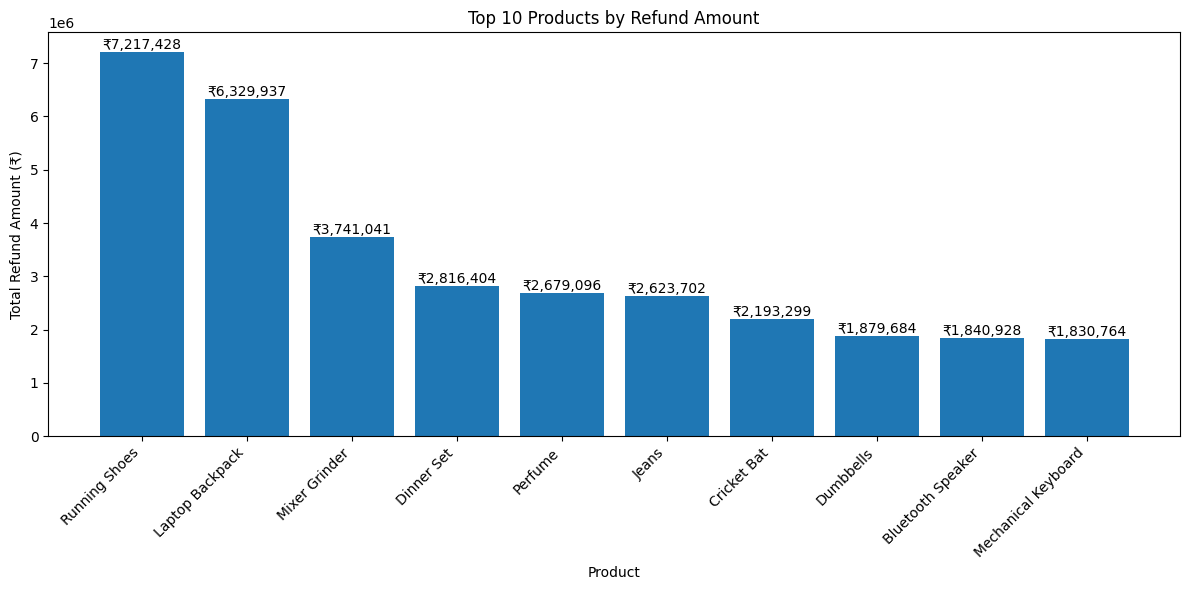

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_refund_products["Product"],
    top_refund_products["Total_Refund_Amount"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Top 10 Products by Refund Amount")
plt.xlabel("Product")
plt.ylabel("Total Refund Amount (₹)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
top_revenue_products = (
    product_analysis
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
    .head(10)
)

top_revenue_products

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40",11.59
2,P003,Bluetooth Speaker,Electronics,5246,192,3.66,"1,840,927.95",51881273,"50,040,345.05",3.55
13,P014,Mixer Grinder,Home & Kitchen,5357,412,7.69,"3,741,041.30",51144240,"47,403,198.70",7.31
1,P002,Mechanical Keyboard,Electronics,5232,201,3.84,"1,830,764.35",49371324,"47,540,559.65",3.71
15,P016,Dinner Set,Home & Kitchen,5144,387,7.52,"2,816,403.65",38914663,"36,098,259.35",7.24
10,P011,Cricket Bat,Sports,5328,318,5.97,"2,193,299.40",38139115,"35,945,815.60",5.75
12,P013,Dumbbells,Sports,5302,326,6.15,"1,879,684.40",31502735,"29,623,050.60",5.97
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35",9.82
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55",10.58


In [ ]:
high_return_products = product_analysis[
    product_analysis["Return_Rate"] > 10
]

high_return_products = high_return_products.sort_values(
    "Return_Rate",
    ascending=False
)

high_return_products

,Product_ID,Product,Category,Total_Orders,Returned_Orders,Return_Rate,Total_Refund_Amount,Total_Revenue,Net_Revenue,Refund_Loss_Percentage
3,P004,Laptop Backpack,Accessories,5326,1393,26.15,"6,329,936.60",24980278,"18,650,341.40",25.34
6,P007,Running Shoes,Clothing,5357,617,11.52,"7,217,427.60",62252038,"55,034,610.40",11.59
5,P006,Jeans,Clothing,5204,575,11.05,"2,623,702.45",24794932,"22,171,229.55",10.58
4,P005,T-Shirt,Clothing,5250,565,10.76,"1,250,819.65",12162049,"10,911,229.35",10.28
7,P008,Face Wash,Beauty,5202,538,10.34,"488,707.60",4699227,"4,210,519.40",10.40
8,P009,Shampoo,Beauty,5227,539,10.31,"597,817.40",6006300,"5,408,482.60",9.95
9,P010,Perfume,Beauty,5215,536,10.28,"2,679,095.65",27283311,"24,604,215.35",9.82


In [ ]:
product_analysis.to_csv(
    "product_return_analysis.csv",
    index=False
)

In [ ]:
product_return_report.to_csv(
    "product_return_report.csv",
    index=False
)

Analysis 5 — Customer Analysis

In [ ]:
transactions_df["Age_Group"] = pd.cut(
    transactions_df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65"
    ]
)

transactions_df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,47,46-55
1,21,18-25
2,31,26-35
3,29,26-35
4,36,36-45


In [ ]:
age_analysis = (
    transactions_df
    .groupby("Age_Group", observed=True)
    .agg(
        Total_Orders=("Order_ID", "count"),
        Returned_Orders=("Returned", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Total_Refund_Amount=("Refund_Amount", "sum")
    )
    .reset_index()
)

age_analysis

,Age_Group,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount
0,18-25,16049,1254,81348326,"6,272,020.65"
1,26-35,20738,1659,103633463,"8,096,647.95"
2,36-45,21230,1712,107654769,"8,558,526.75"
3,46-55,21248,1614,106374519,"8,134,373.90"
4,56-65,20735,1615,104674913,"8,151,026.40"


In [ ]:
age_analysis["Return_Rate"] = (
    age_analysis["Returned_Orders"]
    / age_analysis["Total_Orders"]
) * 100

age_analysis["Return_Rate"] = (
    age_analysis["Return_Rate"].round(2)
)

age_analysis

,Age_Group,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount,Return_Rate
0,18-25,16049,1254,81348326,"6,272,020.65",7.81
1,26-35,20738,1659,103633463,"8,096,647.95",8.00
2,36-45,21230,1712,107654769,"8,558,526.75",8.06
3,46-55,21248,1614,106374519,"8,134,373.90",7.60
4,56-65,20735,1615,104674913,"8,151,026.40",7.79


In [ ]:
age_analysis["Net_Revenue"] = (
    age_analysis["Total_Revenue"]
    - age_analysis["Total_Refund_Amount"]
)

age_analysis

,Age_Group,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount,Return_Rate,Net_Revenue
0,18-25,16049,1254,81348326,"6,272,020.65",7.81,"75,076,305.35"
1,26-35,20738,1659,103633463,"8,096,647.95",8.00,"95,536,815.05"
2,36-45,21230,1712,107654769,"8,558,526.75",8.06,"99,096,242.25"
3,46-55,21248,1614,106374519,"8,134,373.90",7.60,"98,240,145.10"
4,56-65,20735,1615,104674913,"8,151,026.40",7.79,"96,523,886.60"


In [ ]:
membership_analysis = (
    transactions_df
    .groupby("Membership")
    .agg(
        Total_Orders=("Order_ID", "count"),
        Returned_Orders=("Returned", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Total_Refund_Amount=("Refund_Amount", "sum")
    )
    .reset_index()
)

membership_analysis["Return_Rate"] = (
    membership_analysis["Returned_Orders"]
    / membership_analysis["Total_Orders"]
) * 100

membership_analysis["Return_Rate"] = (
    membership_analysis["Return_Rate"].round(2)
)

membership_analysis["Net_Revenue"] = (
    membership_analysis["Total_Revenue"]
    - membership_analysis["Total_Refund_Amount"]
)

membership_analysis

,Membership,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount,Return_Rate,Net_Revenue
0,Gold,14313,1113,72739311,"5,677,211.70",7.78,"67,062,099.30"
1,Platinum,10371,793,51435756,"3,833,456.95",7.65,"47,602,299.05"
2,Regular,51757,4139,260313515,"20,596,147.30",8.00,"239,717,367.70"
3,Silver,23559,1809,119197408,"9,105,779.70",7.68,"110,091,628.30"


In [ ]:
gender_analysis = (
    transactions_df
    .groupby("Gender")
    .agg(
        Total_Orders=("Order_ID", "count"),
        Returned_Orders=("Returned", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Total_Refund_Amount=("Refund_Amount", "sum")
    )
    .reset_index()
)

gender_analysis["Return_Rate"] = (
    gender_analysis["Returned_Orders"]
    / gender_analysis["Total_Orders"]
) * 100

gender_analysis["Return_Rate"] = (
    gender_analysis["Return_Rate"].round(2)
)

gender_analysis["Net_Revenue"] = (
    gender_analysis["Total_Revenue"]
    - gender_analysis["Total_Refund_Amount"]
)

gender_analysis

,Gender,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount,Return_Rate,Net_Revenue
0,Female,48743,3780,245006437,"18,474,608.60",7.75,"226,531,828.40"
1,Male,51257,4074,258679553,"20,737,987.05",7.95,"237,941,565.95"


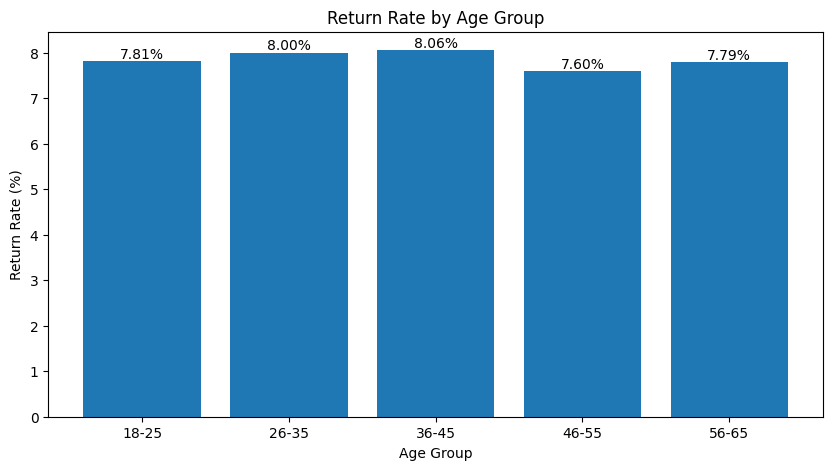

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    age_analysis["Age_Group"].astype(str),
    age_analysis["Return_Rate"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Return Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Return Rate (%)")

plt.show()

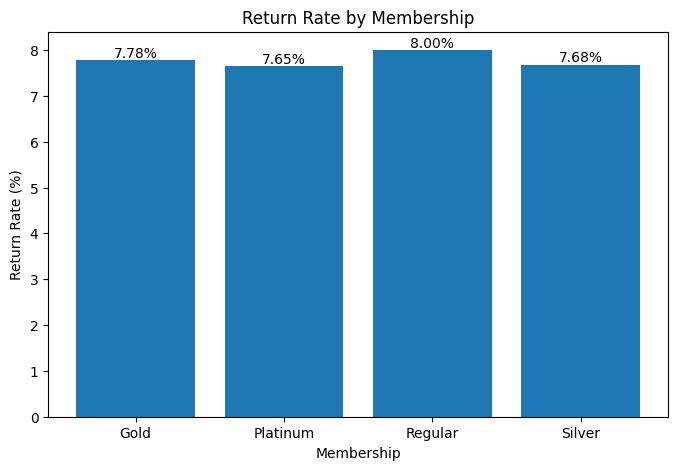

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    membership_analysis["Membership"],
    membership_analysis["Return_Rate"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Return Rate by Membership")
plt.xlabel("Membership")
plt.ylabel("Return Rate (%)")

plt.show()

In [ ]:
age_analysis.to_csv(
    "age_group_analysis.csv",
    index=False
)

membership_analysis.to_csv(
    "membership_analysis.csv",
    index=False
)

gender_analysis.to_csv(
    "gender_analysis.csv",
    index=False
)

Analysis 6 — Time Analysis

In [ ]:
transactions_df["Order_Date"] = pd.to_datetime(
    transactions_df["Order_Date"]
)

transactions_df[["Order_Date"]].head()

,Order_Date
0,2024-07-01
1,2024-11-08
2,2025-07-28
3,2024-08-04
4,2024-06-19


In [ ]:
transactions_df["Month"] = (
    transactions_df["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)

transactions_df[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2024-07-01,2024-07
1,2024-11-08,2024-11
2,2025-07-28,2025-07
3,2024-08-04,2024-08
4,2024-06-19,2024-06


In [ ]:
monthly_analysis = (
    transactions_df
    .groupby("Month")
    .agg(
        Total_Orders=("Order_ID", "count"),
        Returned_Orders=("Returned", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Total_Refund_Amount=("Refund_Amount", "sum")
    )
    .reset_index()
)

monthly_analysis

,Month,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount
0,2024-01,4261,335,21837388,"1,715,298.15"
1,2024-02,3940,286,20130735,"1,356,055.35"
2,2024-03,4348,351,22243588,"1,837,019.10"
3,2024-04,4043,325,20653207,"1,743,434.15"
4,2024-05,4227,338,20727605,"1,699,900.20"
5,2024-06,3960,304,20035717,"1,440,368.30"
6,2024-07,4114,303,20679512,"1,576,017.45"
7,2024-08,4249,329,21380257,"1,663,295.60"
8,2024-09,4114,311,20739073,"1,618,115.70"
9,2024-10,4183,350,21364019,"1,614,916.45"


In [ ]:
monthly_analysis["Return_Rate"] = (
    monthly_analysis["Returned_Orders"]
    / monthly_analysis["Total_Orders"]
) * 100

monthly_analysis["Return_Rate"] = (
    monthly_analysis["Return_Rate"].round(2)
)

monthly_analysis

,Month,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount,Return_Rate
0,2024-01,4261,335,21837388,"1,715,298.15",7.86
1,2024-02,3940,286,20130735,"1,356,055.35",7.26
2,2024-03,4348,351,22243588,"1,837,019.10",8.07
3,2024-04,4043,325,20653207,"1,743,434.15",8.04
4,2024-05,4227,338,20727605,"1,699,900.20",8.00
5,2024-06,3960,304,20035717,"1,440,368.30",7.68
6,2024-07,4114,303,20679512,"1,576,017.45",7.37
7,2024-08,4249,329,21380257,"1,663,295.60",7.74
8,2024-09,4114,311,20739073,"1,618,115.70",7.56
9,2024-10,4183,350,21364019,"1,614,916.45",8.37


In [ ]:
monthly_analysis["Net_Revenue"] = (
    monthly_analysis["Total_Revenue"]
    - monthly_analysis["Total_Refund_Amount"]
)

monthly_analysis

,Month,Total_Orders,Returned_Orders,Total_Revenue,Total_Refund_Amount,Return_Rate,Net_Revenue
0,2024-01,4261,335,21837388,"1,715,298.15",7.86,"20,122,089.85"
1,2024-02,3940,286,20130735,"1,356,055.35",7.26,"18,774,679.65"
2,2024-03,4348,351,22243588,"1,837,019.10",8.07,"20,406,568.90"
3,2024-04,4043,325,20653207,"1,743,434.15",8.04,"18,909,772.85"
4,2024-05,4227,338,20727605,"1,699,900.20",8.00,"19,027,704.80"
5,2024-06,3960,304,20035717,"1,440,368.30",7.68,"18,595,348.70"
6,2024-07,4114,303,20679512,"1,576,017.45",7.37,"19,103,494.55"
7,2024-08,4249,329,21380257,"1,663,295.60",7.74,"19,716,961.40"
8,2024-09,4114,311,20739073,"1,618,115.70",7.56,"19,120,957.30"
9,2024-10,4183,350,21364019,"1,614,916.45",8.37,"19,749,102.55"


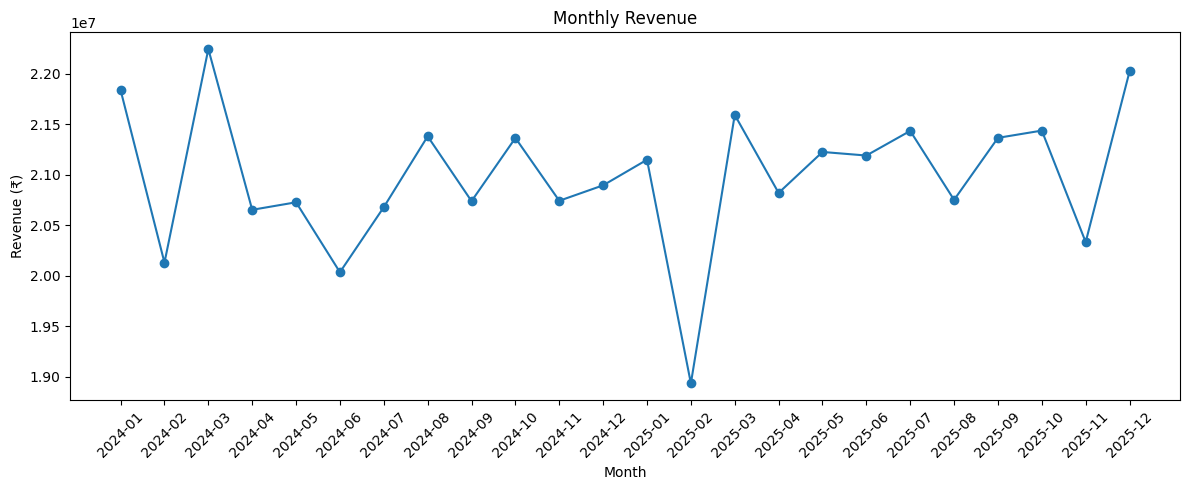

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

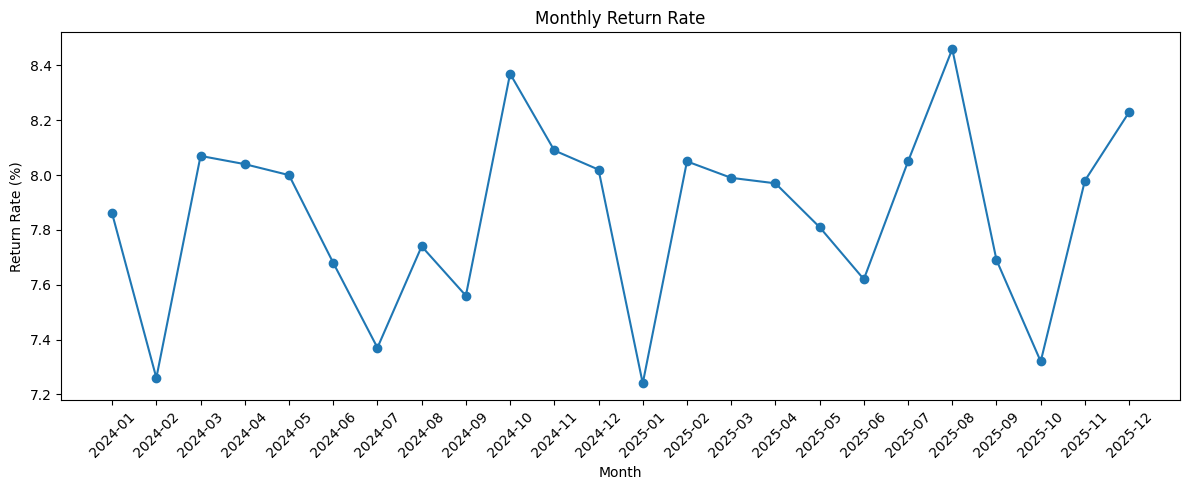

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Return_Rate"],
    marker="o"
)

plt.title("Monthly Return Rate")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
highest_return_month = (
    monthly_analysis
    .sort_values("Return_Rate", ascending=False)
    .iloc[0]
)

print(
    f"Highest Return Rate Month: "
    f"{highest_return_month['Month']}"
)

print(
    f"Return Rate: "
    f"{highest_return_month['Return_Rate']:.2f}%"
)

Highest Return Rate Month: 2025-08
Return Rate: 8.46%


In [ ]:
highest_revenue_month = (
    monthly_analysis
    .sort_values("Total_Revenue", ascending=False)
    .iloc[0]
)

print(
    f"Highest Revenue Month: "
    f"{highest_revenue_month['Month']}"
)

print(
    f"Revenue: "
    f"₹{highest_revenue_month['Total_Revenue']:,.2f}"
)

Highest Revenue Month: 2024-03
Revenue: ₹22,243,588.00


In [ ]:
monthly_analysis.to_csv(
    "monthly_analysis.csv",
    index=False
)

In [ ]:
total_orders = len(transactions_df)

total_returned_orders = transactions_df["Returned"].sum()

total_revenue = transactions_df["Revenue"].sum()

total_refund_amount = transactions_df["Refund_Amount"].sum()

net_revenue = total_revenue - total_refund_amount

overall_return_rate = (
    total_returned_orders / total_orders
) * 100

refund_loss_percentage = (
    total_refund_amount / total_revenue
) * 100

print(f"Total Orders: {total_orders:,}")
print(f"Returned Orders: {total_returned_orders:,}")
print(f"Overall Return Rate: {overall_return_rate:.2f}%")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Refund Amount: ₹{total_refund_amount:,.2f}")
print(f"Net Revenue: ₹{net_revenue:,.2f}")
print(f"Refund Loss Percentage: {refund_loss_percentage:.2f}%")

Total Orders: 100,000
Returned Orders: 7,854
Overall Return Rate: 7.85%
Total Revenue: ₹503,685,990.00
Total Refund Amount: ₹39,212,595.65
Net Revenue: ₹464,473,394.35
Refund Loss Percentage: 7.79%


In [ ]:
worst_seller = seller_analysis.sort_values(
    "Return_Rate",
    ascending=False
).iloc[0]

print(f"Worst Seller: {worst_seller['Seller_ID']}")
print(f"Return Rate: {worst_seller['Return_Rate']:.2f}%")
print(
    f"Refund Loss: "
    f"₹{worst_seller['Total_Refund_Amount']:,.2f}"
)
print(
    f"Net Revenue: "
    f"₹{worst_seller['Net_Revenue']:,.2f}"
)

Worst Seller: S010
Return Rate: 26.15%
Refund Loss: ₹6,329,936.60
Net Revenue: ₹18,650,341.40


In [ ]:
worst_category = category_analysis.sort_values(
    "Return_Rate",
    ascending=False
).iloc[0]

print(f"Worst Category: {worst_category['Category']}")
print(f"Return Rate: {worst_category['Return_Rate']:.2f}%")
print(
    f"Refund Loss: "
    f"₹{worst_category['Total_Refund_Amount']:,.2f}"
)

Worst Category: Accessories
Return Rate: 26.15%
Refund Loss: ₹6,329,936.60


In [ ]:
worst_product = product_analysis.sort_values(
    "Return_Rate",
    ascending=False
).iloc[0]

print(f"Worst Product: {worst_product['Product']}")
print(f"Category: {worst_product['Category']}")
print(f"Return Rate: {worst_product['Return_Rate']:.2f}%")
print(
    f"Refund Loss: "
    f"₹{worst_product['Total_Refund_Amount']:,.2f}"
)

Worst Product: Laptop Backpack
Category: Accessories
Return Rate: 26.15%
Refund Loss: ₹6,329,936.60


In [ ]:
top_return_reason = return_reason_counts.iloc[0]

print(
    f"Most Common Return Reason: "
    f"{top_return_reason['Return_Reason']}"
)

print(
    f"Number of Returns: "
    f"{top_return_reason['No_of_Returns']:,}"
)

Most Common Return Reason: Size Issue
Number of Returns: 1,143


In [ ]:
seller_analysis.to_csv(
    "final_seller_analysis.csv",
    index=False
)

category_analysis.to_csv(
    "final_category_analysis.csv",
    index=False
)

product_analysis.to_csv(
    "final_product_analysis.csv",
    index=False
)

age_analysis.to_csv(
    "final_age_analysis.csv",
    index=False
)

membership_analysis.to_csv(
    "final_membership_analysis.csv",
    index=False
)

gender_analysis.to_csv(
    "final_gender_analysis.csv",
    index=False
)

monthly_analysis.to_csv(
    "final_monthly_analysis.csv",
    index=False
)

In [ ]:
transactions_df.to_csv(
    "final_transactions.csv",
    index=False
)